In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis
from scipy.fft import fft
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import GridSearchCV, cross_val_score

print('All libraries imported successfully')

All libraries imported successfully


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jorgeromn/human-activity-recognition-smartphones-data-set")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/jorgeromn/human-activity-recognition-smartphones-data-set


In [5]:
import os
for root, dirs, files in os.walk(path):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/jorgeromn/human-activity-recognition-smartphones-data-set/UCI HAR Dataset/activity_labels.txt
/kaggle/input/datasets/jorgeromn/human-activity-recognition-smartphones-data-set/UCI HAR Dataset/README.txt
/kaggle/input/datasets/jorgeromn/human-activity-recognition-smartphones-data-set/UCI HAR Dataset/features_info.txt
/kaggle/input/datasets/jorgeromn/human-activity-recognition-smartphones-data-set/UCI HAR Dataset/features.txt
/kaggle/input/datasets/jorgeromn/human-activity-recognition-smartphones-data-set/UCI HAR Dataset/test/subject_test.txt
/kaggle/input/datasets/jorgeromn/human-activity-recognition-smartphones-data-set/UCI HAR Dataset/test/y_test.txt
/kaggle/input/datasets/jorgeromn/human-activity-recognition-smartphones-data-set/UCI HAR Dataset/test/X_test.txt
/kaggle/input/datasets/jorgeromn/human-activity-recognition-smartphones-data-set/UCI HAR Dataset/test/Inertial Signals/body_acc_y_test.txt
/kaggle/input/datasets/jorgeromn/human-activity-recognition-smartp

### Cell 1 — Load dataset

In [6]:
def load_data():
    print('Loading UCI HAR Dataset...')
    
    data_folder = path + '/UCI HAR Dataset/'

    features = pd.read_csv(
        data_folder + 'features.txt',
        sep=r'\s+',
        header=None,
        names=['id', 'name']
    )

    columnNames = features['name'].values

    labelsMap = pd.read_csv(
        data_folder + 'activity_labels.txt',
        sep=r'\s+',
        header=None,
        names=['id', 'activity_name']
    )

    def read_set(set_name):
        X = pd.read_csv(
            f'{data_folder}{set_name}/X_{set_name}.txt',
            sep=r'\s+',
            header=None
        )
        X.columns = columnNames

        y = pd.read_csv(
            f'{data_folder}{set_name}/y_{set_name}.txt',
            sep=r'\s+',
            header=None,
            names=['Activity_ID']
        )
        y['Activity_Name'] = y['Activity_ID'].map(
            labelsMap.set_index('id')['activity_name']
        )

        subject = pd.read_csv(
            f'{data_folder}{set_name}/subject_{set_name}.txt',
            sep=r'\s+',
            header=None,
            names=['Subject_ID']
        )

        return pd.concat([subject, y, X], axis=1)

    train_df = read_set('train')
    test_df  = read_set('test')

    print(f'Train shape : {train_df.shape}')
    print(f'Test  shape : {test_df.shape}')

    return train_df, test_df


train_data, test_data = load_data()
train_data.head(3)

Loading UCI HAR Dataset...
Train shape : (7352, 564)
Test  shape : (2947, 564)


,Subject_ID,Activity_ID,Activity_Name,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,1,5,STANDING,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,1,5,STANDING,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,1,5,STANDING,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118


### Cell 2 — Load raw inertial signals

In [7]:
def load_inertial_signals(set_name):
    print(f'Loading raw signals for {set_name}...')

    data_folder = path + f'/UCI HAR Dataset/{set_name}/Inertial Signals/'

    filenames = [
        'body_acc_x_','body_acc_y_','body_acc_z_',
        'body_gyro_x_','body_gyro_y_','body_gyro_z_',
        'total_acc_x_','total_acc_y_','total_acc_z_'
    ]

    signals = []

    for name in filenames:
        data = pd.read_csv(
            f'{data_folder}{name}{set_name}.txt',
            sep=r'\s+',
            header=None
        )
        signals.append(data.values)

    return np.transpose(np.array(signals), (1, 2, 0))


X_train_raw = load_inertial_signals('train')
X_test_raw  = load_inertial_signals('test')

print(f'X_train_raw shape : {X_train_raw.shape}')
print(f'X_test_raw  shape : {X_test_raw.shape}')

Loading raw signals for train...
Loading raw signals for test...
X_train_raw shape : (7352, 128, 9)
X_test_raw  shape : (2947, 128, 9)


### Cell 3 — Data quality checks

In [8]:
print('=== Data Quality Report ===')
print(f'NaN in train     : {train_data.isnull().sum().sum()}')
print(f'NaN in test      : {test_data.isnull().sum().sum()}')
print(f'Duplicate rows   : {train_data.duplicated().sum()}')
print()
print('=== Train / Test Split ===')
total = train_data.shape[0] + test_data.shape[0]
print(f'Train : {train_data.shape[0]} samples ({train_data.shape[0]/total:.0%})')
print(f'Test  : {test_data.shape[0]} samples ({test_data.shape[0]/total:.0%})')
print()
print('=== Class Distribution (train) ===')
print(train_data['Activity_Name'].value_counts())

=== Data Quality Report ===
NaN in train     : 0
NaN in test      : 0
Duplicate rows   : 0

=== Train / Test Split ===
Train : 7352 samples (71%)
Test  : 2947 samples (29%)

=== Class Distribution (train) ===
Activity_Name
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


### Cell 4 — Activity class balance

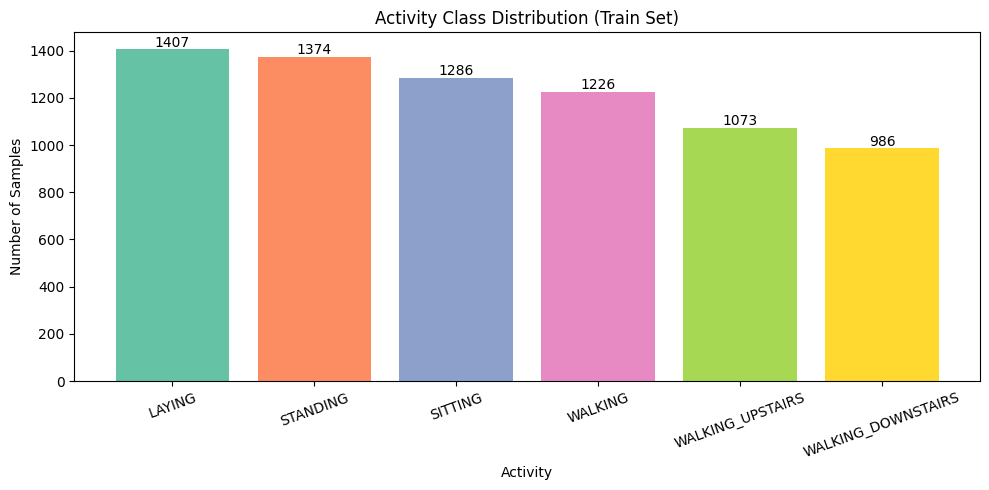

Insight: Classes are roughly balanced — no major imbalance issue.


In [9]:
plt.figure(figsize=(10, 5))
counts = train_data['Activity_Name'].value_counts()
bars = plt.bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)))
plt.title('Activity Class Distribution (Train Set)')
plt.xlabel('Activity')
plt.ylabel('Number of Samples')
plt.xticks(rotation=20)
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()
print('Insight: Classes are roughly balanced — no major imbalance issue.')

### Cell 5 — Sensor signal plots per activity

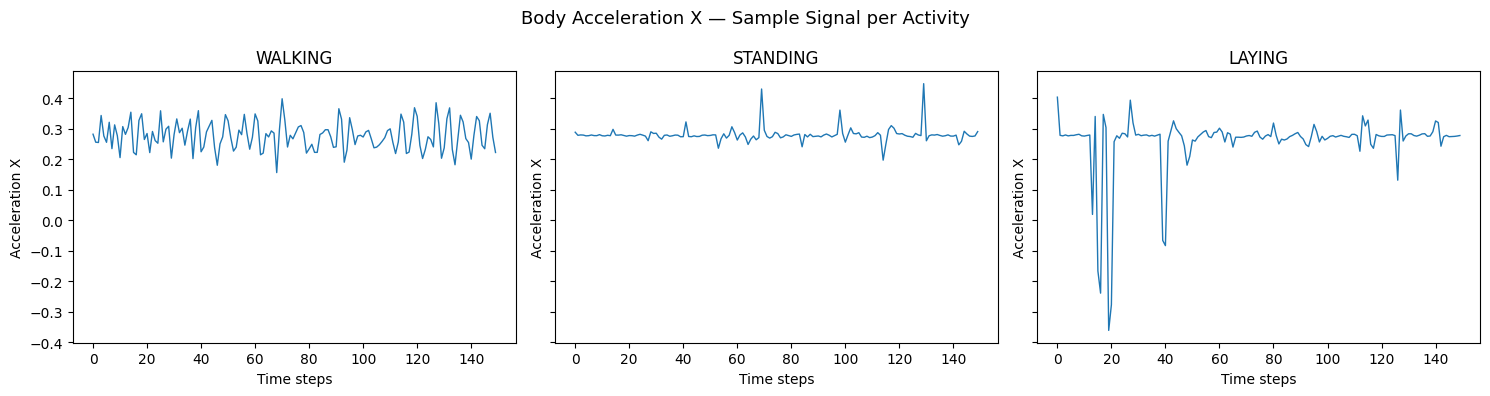

Insight: WALKING has clear periodic oscillations. STANDING and LAYING are near-flat.


In [10]:
activities  = ['WALKING', 'STANDING', 'LAYING']
signal_col  = 'tBodyAcc-mean()-X'
fig, axes   = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, activity in zip(axes, activities):
    subset = train_data[train_data['Activity_Name'] == activity][signal_col].values[:150]
    ax.plot(subset, linewidth=1)
    ax.set_title(f'{activity}')
    ax.set_xlabel('Time steps')
    ax.set_ylabel('Acceleration X')

plt.suptitle('Body Acceleration X — Sample Signal per Activity', fontsize=13)
plt.tight_layout()
plt.show()
print('Insight: WALKING has clear periodic oscillations. STANDING and LAYING are near-flat.')

### Cell 6 — Correlation matrix (first 20 features)

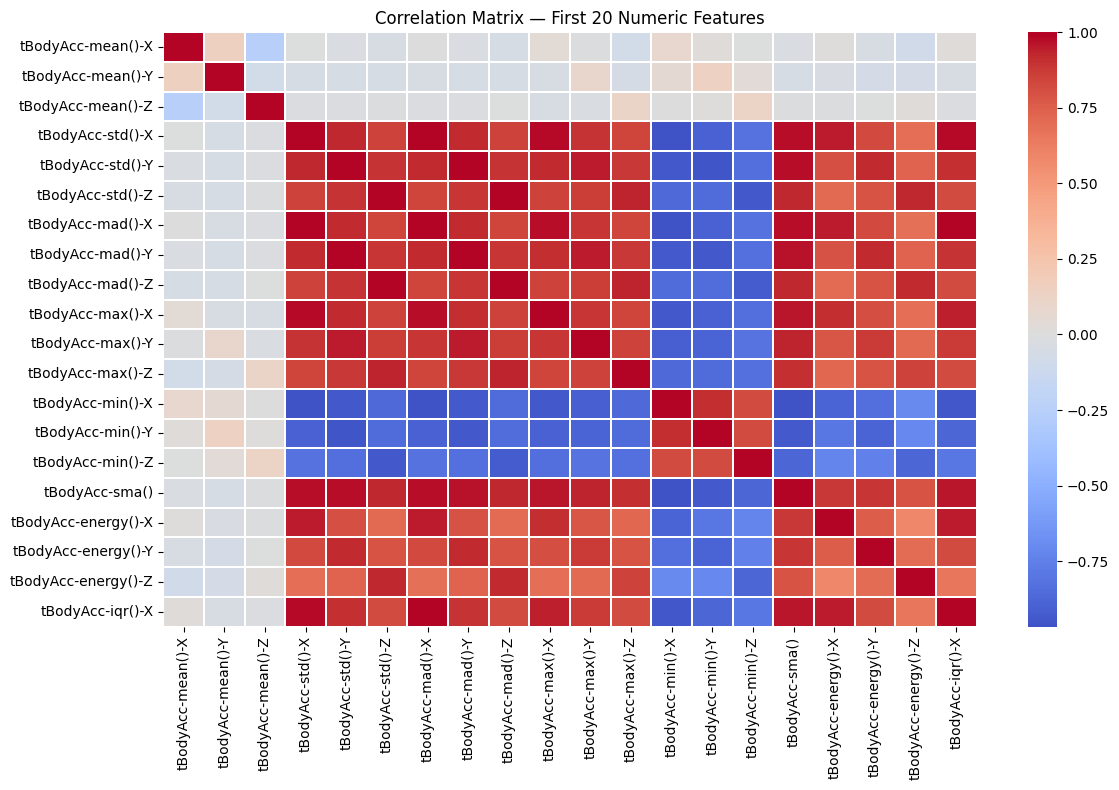

Insight: High correlation between some body acceleration features — expected for XYZ axes.


In [11]:
numeric_data = train_data.select_dtypes(include=['number'])
corr = numeric_data.iloc[:, 2:22].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.3, annot=False)
plt.title('Correlation Matrix — First 20 Numeric Features')
plt.tight_layout()
plt.show()
print('Insight: High correlation between some body acceleration features — expected for XYZ axes.')

### Cell 7 — Distribution plots

/tmp/ipykernel_57/1652785480.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Activity_Name', y=feature, data=train_data, ax=axes[1], palette='Set2')


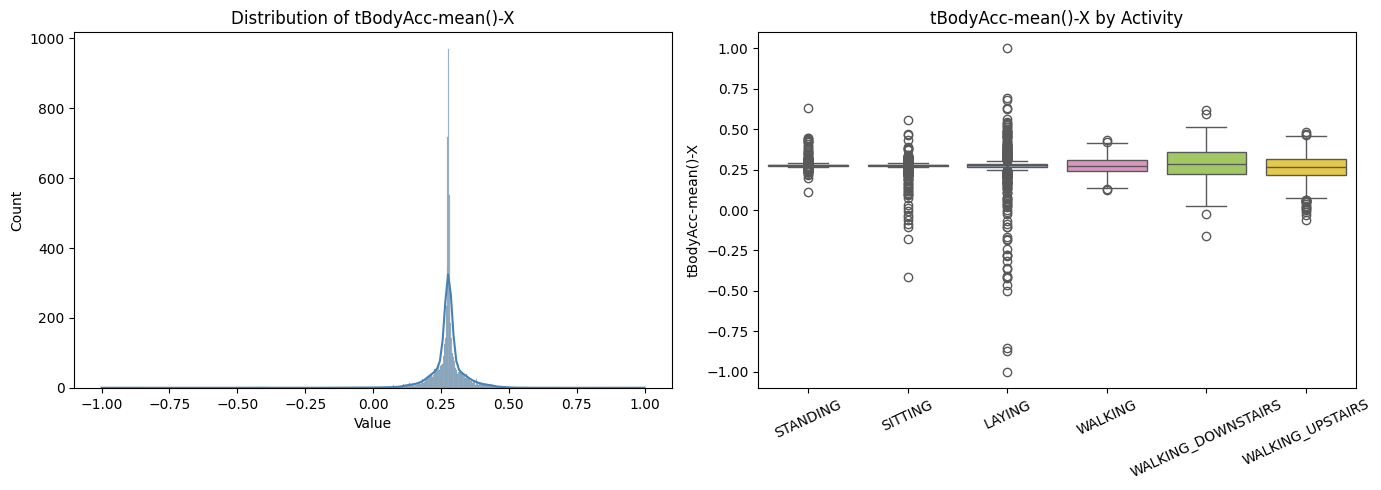

Insight: Body acceleration X clearly separates walking activities from static ones.


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(numeric_data.iloc[:, 2], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'Distribution of {numeric_data.columns[2]}')
axes[0].set_xlabel('Value')


feature = 'tBodyAcc-mean()-X'
sns.boxplot(x='Activity_Name', y=feature, data=train_data, ax=axes[1], palette='Set2')
axes[1].set_title(f'{feature} by Activity')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()
print('Insight: Body acceleration X clearly separates walking activities from static ones.')

### Cell 8 — Signal names

In [13]:
SIGNAL_NAMES = [
    'body_acc_x','body_acc_y','body_acc_z',
    'body_gyro_x','body_gyro_y','body_gyro_z',
    'total_acc_x','total_acc_y','total_acc_z'
]
print(f'Number of signals : {len(SIGNAL_NAMES)}')
print(f'Signal names      : {SIGNAL_NAMES}')

Number of signals : 9
Signal names      : ['body_acc_x', 'body_acc_y', 'body_acc_z', 'body_gyro_x', 'body_gyro_y', 'body_gyro_z', 'total_acc_x', 'total_acc_y', 'total_acc_z']


### Cell 9 — Time-domain features (mean, std, min, max, median, skew, kurtosis)

In [14]:
def extract_time_domain_features(raw_data):
    print('Extracting time-domain features...')
    records = []
    for sample in raw_data:
        row = {}
        for i, sig_name in enumerate(SIGNAL_NAMES):
            signal = sample[:, i]
            row[f'{sig_name}_mean']     = np.mean(signal)
            row[f'{sig_name}_std']      = np.std(signal)
            row[f'{sig_name}_min']      = np.min(signal)
            row[f'{sig_name}_max']      = np.max(signal)
            row[f'{sig_name}_median']   = np.median(signal)
            row[f'{sig_name}_skew']     = skew(signal)
            row[f'{sig_name}_kurtosis'] = kurtosis(signal)
        records.append(row)
    df = pd.DataFrame(records)
    print(f'  Output shape : {df.shape}  (9 signals x 7 stats = 63 features)')
    return df

X_train_time = extract_time_domain_features(X_train_raw)
X_test_time  = extract_time_domain_features(X_test_raw)
X_train_time.head(3)

Extracting time-domain features...
  Output shape : (7352, 63)  (9 signals x 7 stats = 63 features)
Extracting time-domain features...
  Output shape : (2947, 63)  (9 signals x 7 stats = 63 features)


,body_acc_x_mean,body_acc_x_std,body_acc_x_min,body_acc_x_max,body_acc_x_median,body_acc_x_skew,body_acc_x_kurtosis,body_acc_y_mean,body_acc_y_std,body_acc_y_min,...,total_acc_y_median,total_acc_y_skew,total_acc_y_kurtosis,total_acc_z_mean,total_acc_z_std,total_acc_z_min,total_acc_z_max,total_acc_z_median,total_acc_z_skew,total_acc_z_kurtosis
0,0.002269,0.002941,-0.004294,0.010810,0.002025,0.481111,-0.395797,-0.001655,0.004601,-0.012610,...,-0.124302,-0.034474,-0.408672,0.099732,0.003970,0.088742,0.109485,0.099841,0.071125,0.493800
1,0.000174,0.001981,-0.006706,0.005251,0.000110,-0.480776,1.472747,0.000382,0.005930,-0.012610,...,-0.123188,0.488232,0.163722,0.096939,0.004918,0.081100,0.105788,0.097748,-1.084209,1.257869
2,0.000428,0.002908,-0.010483,0.008167,0.000627,-0.565241,1.802622,-0.001222,0.007310,-0.015333,...,-0.125918,0.366785,-0.640148,0.092897,0.006145,0.081100,0.105788,0.093636,-0.144007,-0.716645


### Cell 10 — Frequency-domain features (FFT)

In [15]:
def spectral_entropy(signal):
    fft_vals = np.abs(fft(signal))[:len(signal)//2]
    power    = fft_vals ** 2
    total    = np.sum(power)
    if total == 0:
        return 0.0
    prob = power / total
    prob = prob[prob > 0]
    return -np.sum(prob * np.log2(prob))

def extract_fft_features(raw_data, sampling_rate=50):
    print('Extracting FFT features...')
    n_timesteps = raw_data.shape[1]
    freqs       = np.fft.fftfreq(n_timesteps, d=1.0/sampling_rate)[:n_timesteps//2]
    records = []
    for sample in raw_data:
        row = {}
        for i, sig_name in enumerate(SIGNAL_NAMES):
            signal   = sample[:, i]
            fft_vals = np.abs(fft(signal))[:n_timesteps//2]
            row[f'{sig_name}_fft_dominant_freq']    = freqs[np.argmax(fft_vals)]
            row[f'{sig_name}_fft_energy']           = np.sum(fft_vals ** 2)
            row[f'{sig_name}_fft_spectral_entropy'] = spectral_entropy(signal)
        records.append(row)
    df = pd.DataFrame(records)
    print(f'  Output shape : {df.shape}  (9 signals x 3 stats = 27 features)')
    return df

X_train_fft = extract_fft_features(X_train_raw)
X_test_fft  = extract_fft_features(X_test_raw)
X_train_fft.head(3)

Extracting FFT features...
  Output shape : (7352, 27)  (9 signals x 3 stats = 27 features)
Extracting FFT features...
  Output shape : (2947, 27)  (9 signals x 3 stats = 27 features)


,body_acc_x_fft_dominant_freq,body_acc_x_fft_energy,body_acc_x_fft_spectral_entropy,body_acc_y_fft_dominant_freq,body_acc_y_fft_energy,body_acc_y_fft_spectral_entropy,body_acc_z_fft_dominant_freq,body_acc_z_fft_energy,body_acc_z_fft_spectral_entropy,body_gyro_x_fft_dominant_freq,...,body_gyro_z_fft_spectral_entropy,total_acc_x_fft_dominant_freq,total_acc_x_fft_energy,total_acc_x_fft_spectral_entropy,total_acc_y_fft_dominant_freq,total_acc_y_fft_energy,total_acc_y_fft_spectral_entropy,total_acc_z_fft_dominant_freq,total_acc_z_fft_energy,total_acc_z_fft_spectral_entropy
0,0.00000,0.155185,2.610402,0.390625,0.218277,3.594107,0.390625,3.886445,2.556959,0.000000,...,1.344905,0.0,17022.704179,0.000040,0.0,253.073153,0.006050,0.0,163.091410,0.012904
1,7.03125,0.032640,4.761714,0.390625,0.290422,3.365968,0.000000,1.252940,2.680912,0.000000,...,2.333451,0.0,17027.498428,0.000045,0.0,247.813017,0.012676,0.0,154.162921,0.019843
2,0.78125,0.072294,4.779093,0.390625,0.462221,2.989540,0.390625,0.424719,3.435523,0.390625,...,3.248716,0.0,17043.526416,0.000098,0.0,256.328623,0.019163,0.0,141.700207,0.030712


### Cell 11 — Combine all features (63 + 27 = 90)

In [16]:
X_train_feats = pd.concat([X_train_time, X_train_fft], axis=1)
X_test_feats  = pd.concat([X_test_time,  X_test_fft],  axis=1)
print(f'X_train_feats : {X_train_feats.shape}')
print(f'X_test_feats  : {X_test_feats.shape}')
print(f'Total features: {X_train_feats.shape[1]}  (63 time-domain + 27 FFT)')

X_train_feats : (7352, 90)
X_test_feats  : (2947, 90)
Total features: 90  (63 time-domain + 27 FFT)


### Cell 12 — StandardScaler (fit on train only)

In [17]:
scaler         = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_feats), columns=X_train_feats.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_feats),      columns=X_test_feats.columns)
print(f'Train scaled shape : {X_train_scaled.shape}')
print(f'Test  scaled shape : {X_test_scaled.shape}')
print('\nVerify — train mean should be ~0 and std ~1:')
print(X_train_scaled.describe().loc[['mean','std']].round(3).iloc[:, :5])

Train scaled shape : (7352, 90)
Test  scaled shape : (2947, 90)

Verify — train mean should be ~0 and std ~1:
      body_acc_x_mean  body_acc_x_std  body_acc_x_min  body_acc_x_max  \
mean              0.0             0.0             0.0            -0.0   
std               1.0             1.0             1.0             1.0   

      body_acc_x_median  
mean               -0.0  
std                 1.0  


### Cell 13 — Attach labels and export CSVs

In [18]:
train_labels = train_data[['Subject_ID','Activity_ID','Activity_Name']].reset_index(drop=True)
test_labels  = test_data[['Subject_ID','Activity_ID','Activity_Name']].reset_index(drop=True)

train_final = pd.concat([train_labels, X_train_scaled.reset_index(drop=True)], axis=1)
test_final  = pd.concat([test_labels,  X_test_scaled.reset_index(drop=True)],  axis=1)

train_final.to_csv('train_features.csv', index=False)
test_final.to_csv('test_features.csv',   index=False)

print('Saved: train_features.csv')
print('Saved: test_features.csv')
print(f'\ntrain_final shape : {train_final.shape}')
print(f'test_final  shape : {test_final.shape}')
train_final.head(3)

Saved: train_features.csv
Saved: test_features.csv

train_final shape : (7352, 93)
test_final  shape : (2947, 93)


,Subject_ID,Activity_ID,Activity_Name,body_acc_x_mean,body_acc_x_std,body_acc_x_min,body_acc_x_max,body_acc_x_median,body_acc_x_skew,body_acc_x_kurtosis,...,body_gyro_z_fft_spectral_entropy,total_acc_x_fft_dominant_freq,total_acc_x_fft_energy,total_acc_x_fft_spectral_entropy,total_acc_y_fft_dominant_freq,total_acc_y_fft_energy,total_acc_y_fft_spectral_entropy,total_acc_z_fft_dominant_freq,total_acc_z_fft_energy,total_acc_z_fft_spectral_entropy
0,1,5,STANDING,0.200642,-0.868814,0.906009,-0.856036,0.587177,0.383365,-0.331063,...,-1.676605,-0.04378,0.610645,-0.550501,-0.129234,-0.587056,-0.818857,-0.274773,-0.566725,-0.812263
1,1,5,STANDING,0.055948,-0.875426,0.895998,-0.871359,0.544547,-1.181161,0.631206,...,-0.703240,-0.04378,0.611394,-0.550488,-0.129234,-0.588493,-0.813157,-0.274773,-0.569294,-0.807098
2,1,5,STANDING,0.073515,-0.869039,0.880323,-0.863323,0.556060,-1.318546,0.801087,...,0.197969,-0.04378,0.613897,-0.550355,-0.129234,-0.586166,-0.807577,-0.274773,-0.572879,-0.799007


### Cell 14 — PCA Visualization (Dimensionality Reduction)

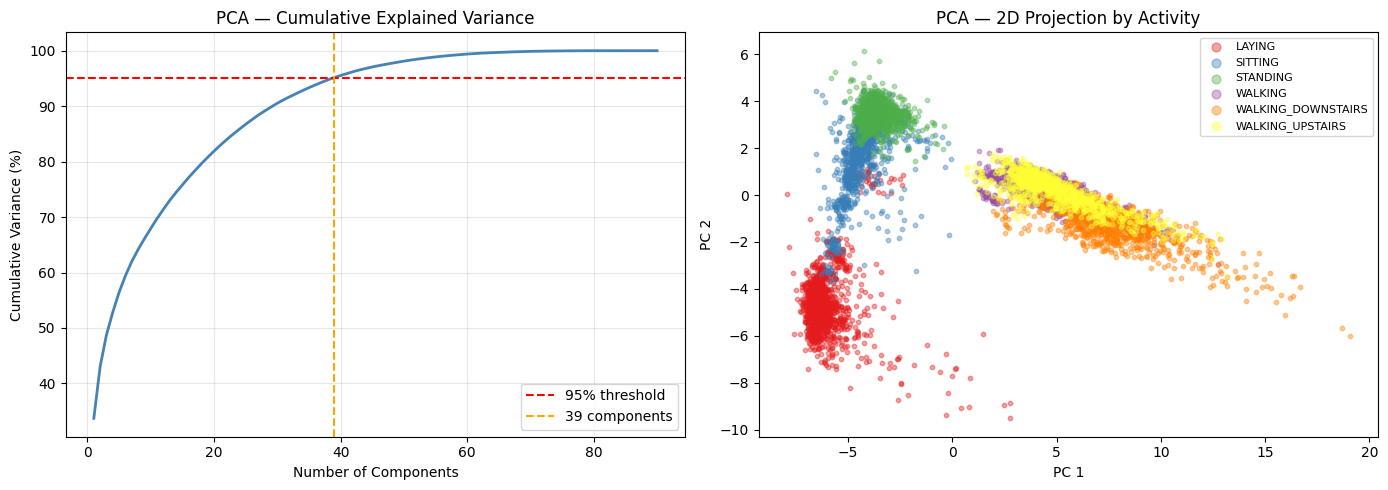

Insight: 39 components explain 95% of variance (out of 90 original features)


In [19]:
feature_cols = X_train_scaled.columns.tolist()
X_train      = train_final[feature_cols]
y_train      = train_final['Activity_ID']
X_test       = test_final[feature_cols]
y_test       = test_final['Activity_ID']

pca_full     = PCA()
pca_full.fit(X_train)
cumvar        = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_95          = np.argmax(cumvar >= 95) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].plot(range(1, len(cumvar)+1), cumvar, color='steelblue', linewidth=2)
axes[0].axhline(y=95, color='red', linestyle='--', label='95% threshold')
axes[0].axvline(x=n_95, color='orange', linestyle='--', label=f'{n_95} components')
axes[0].set_title('PCA — Cumulative Explained Variance')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Variance (%)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


pca2d     = PCA(n_components=2)
X_pca2d   = pca2d.fit_transform(X_train)
activity_names = train_final['Activity_Name'].values
unique_acts    = np.unique(activity_names)
colors         = sns.color_palette('Set1', len(unique_acts))

for act, col in zip(unique_acts, colors):
    mask = activity_names == act
    axes[1].scatter(X_pca2d[mask, 0], X_pca2d[mask, 1], label=act, alpha=0.4, s=10, color=col)

axes[1].set_title('PCA — 2D Projection by Activity')
axes[1].set_xlabel('PC 1')
axes[1].set_ylabel('PC 2')
axes[1].legend(markerscale=2, fontsize=8)

plt.tight_layout()
plt.show()
print(f'Insight: {n_95} components explain 95% of variance (out of {X_train.shape[1]} original features)')

### Cell 15 — LDA Visualization

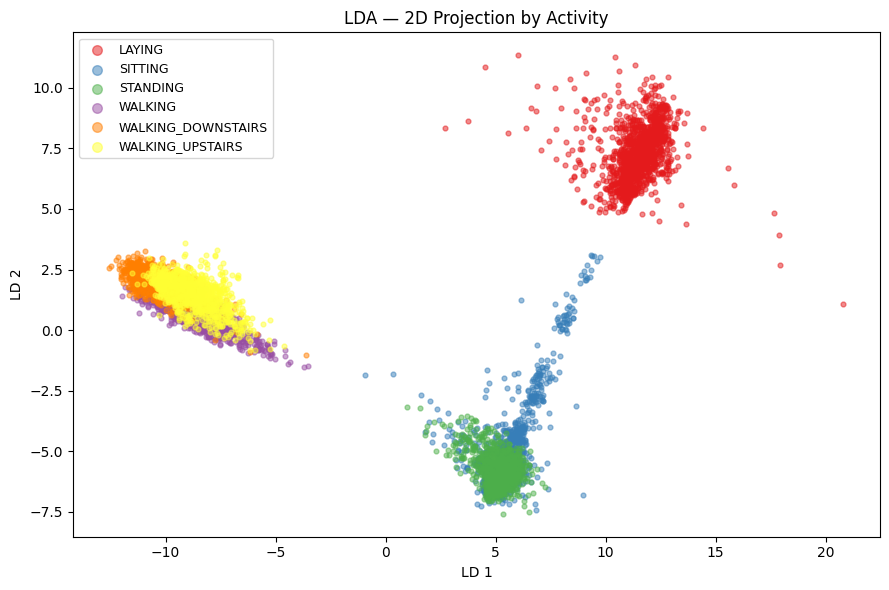

Insight: LDA separates static activities (LAYING, STANDING, SITTING) from dynamic ones clearly.


In [20]:
lda     = LDA(n_components=2)
X_lda2d = lda.fit_transform(X_train, y_train)

plt.figure(figsize=(9, 6))
for act, col in zip(unique_acts, colors):
    mask = activity_names == act
    plt.scatter(X_lda2d[mask, 0], X_lda2d[mask, 1], label=act, alpha=0.5, s=12, color=col)

plt.title('LDA — 2D Projection by Activity')
plt.xlabel('LD 1')
plt.ylabel('LD 2')
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()
print('Insight: LDA separates static activities (LAYING, STANDING, SITTING) from dynamic ones clearly.')

### Cell 16 — Encode labels

In [21]:
le          = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print('Classes:', le.classes_)
print('Encoded:', le.transform(le.classes_))

Classes: [1 2 3 4 5 6]
Encoded: [0 1 2 3 4 5]


### Cell 17 — Train all models (KNN, Naive Bayes, Random Forest, Gradient Boosting)

In [22]:
models = {
    'KNN'               : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'       : GaussianNB(),
    'Random Forest'     : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting' : GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = []
trained_models = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train, y_train_enc)
    y_pred = model.predict(X_test)
    acc    = accuracy_score(y_test_enc, y_pred)
    f1     = f1_score(y_test_enc, y_pred, average='weighted')
    roc    = roc_auc_score(y_test_enc, model.predict_proba(X_test), multi_class='ovr', average='weighted')
    results.append({'Model': name, 'Accuracy': round(acc,4), 'F1 Score': round(f1,4), 'ROC AUC': round(roc,4)})
    trained_models[name] = (model, y_pred)
    print(f'  Accuracy: {acc:.4f} | F1: {f1:.4f} | ROC AUC: {roc:.4f}')

results_df = pd.DataFrame(results)
print('\n=== Results Summary ===')
print(results_df.to_string(index=False))

Training KNN...
  Accuracy: 0.8514 | F1: 0.8517 | ROC AUC: 0.9717
Training Naive Bayes...
  Accuracy: 0.8405 | F1: 0.8344 | ROC AUC: 0.9820
Training Random Forest...
  Accuracy: 0.9019 | F1: 0.9017 | ROC AUC: 0.9914
Training Gradient Boosting...
  Accuracy: 0.9104 | F1: 0.9103 | ROC AUC: 0.9924

=== Results Summary ===
            Model  Accuracy  F1 Score  ROC AUC
              KNN    0.8514    0.8517   0.9717
      Naive Bayes    0.8405    0.8344   0.9820
    Random Forest    0.9019    0.9017   0.9914
Gradient Boosting    0.9104    0.9103   0.9924


### Cell 18 — Confusion matrices for all models

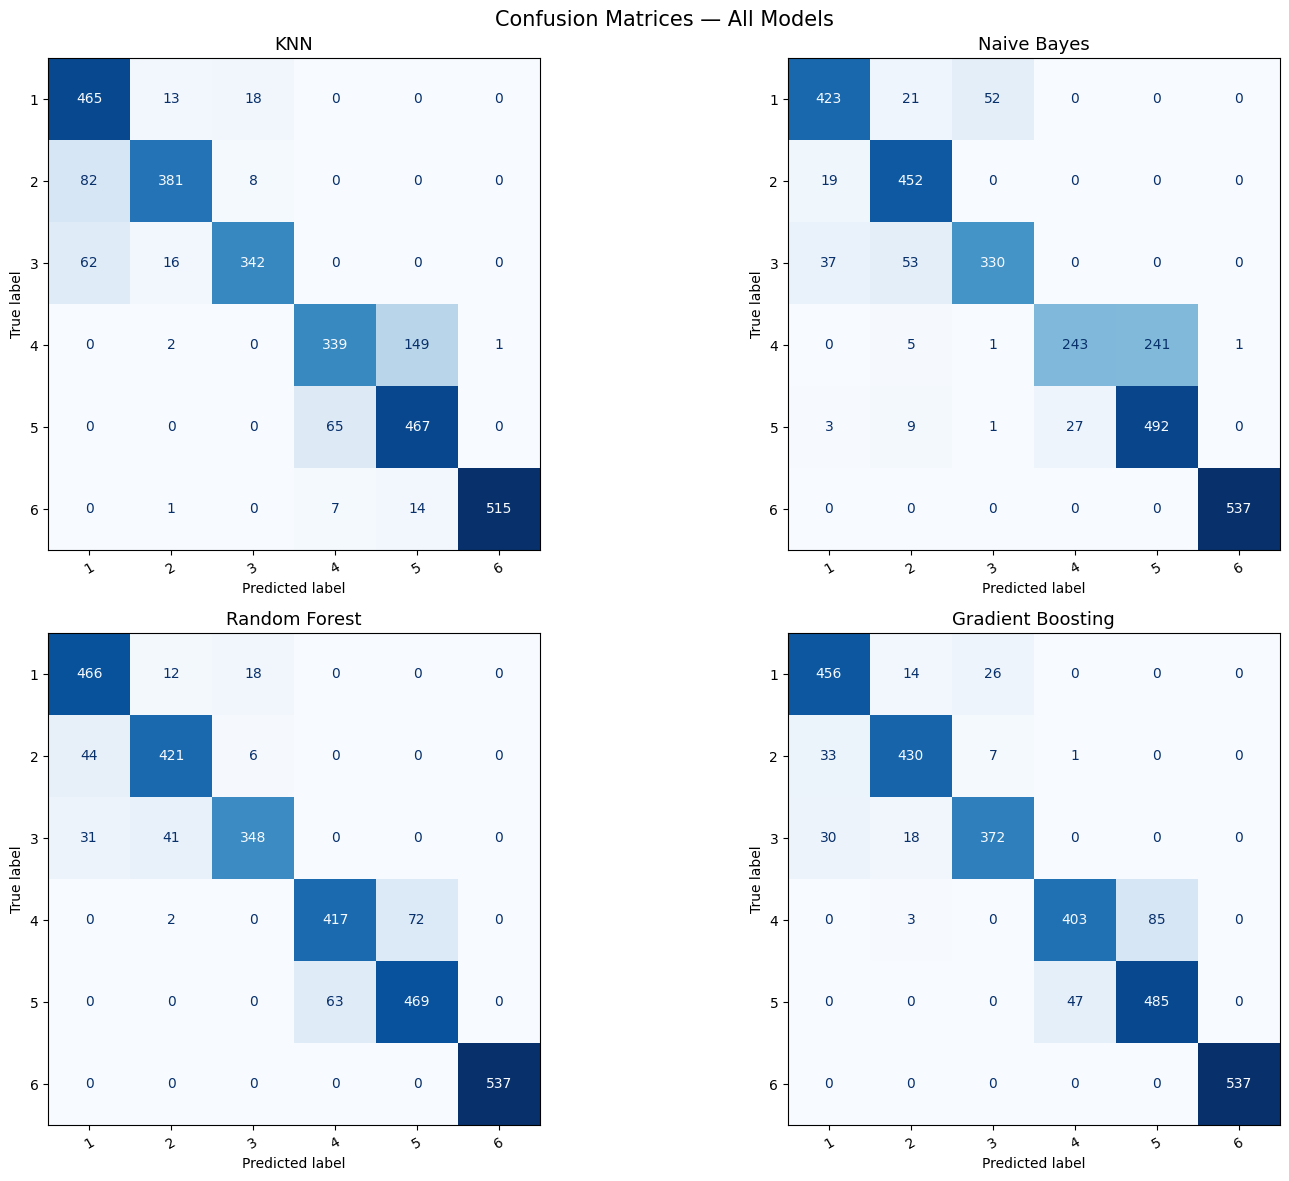

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, (name, (model, y_pred)) in zip(axes, trained_models.items()):
    cm = confusion_matrix(y_test_enc, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{name}', fontsize=13)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — All Models', fontsize=15)
plt.tight_layout()
plt.show()

### Cell 19 — Hyperparameter tuning (KNN & Random Forest)

In [24]:
print('Tuning KNN...')
knn_params = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_grid   = GridSearchCV(KNeighborsClassifier(), knn_params, cv=3, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train_enc)
print(f'  Best k : {knn_grid.best_params_}  |  CV Accuracy : {knn_grid.best_score_:.4f}')

print('Tuning Random Forest...')
rf_params = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
rf_grid   = GridSearchCV(RandomForestClassifier(random_state=42), rf_params, cv=3, scoring='accuracy', n_jobs=-1)
rf_grid.fit(X_train, y_train_enc)
print(f'  Best params : {rf_grid.best_params_}  |  CV Accuracy : {rf_grid.best_score_:.4f}')

Tuning KNN...
  Best k : {'n_neighbors': 9}  |  CV Accuracy : 0.8679
Tuning Random Forest...
  Best params : {'max_depth': 10, 'n_estimators': 50}  |  CV Accuracy : 0.8852


### Cell 20 — Final results bar chart

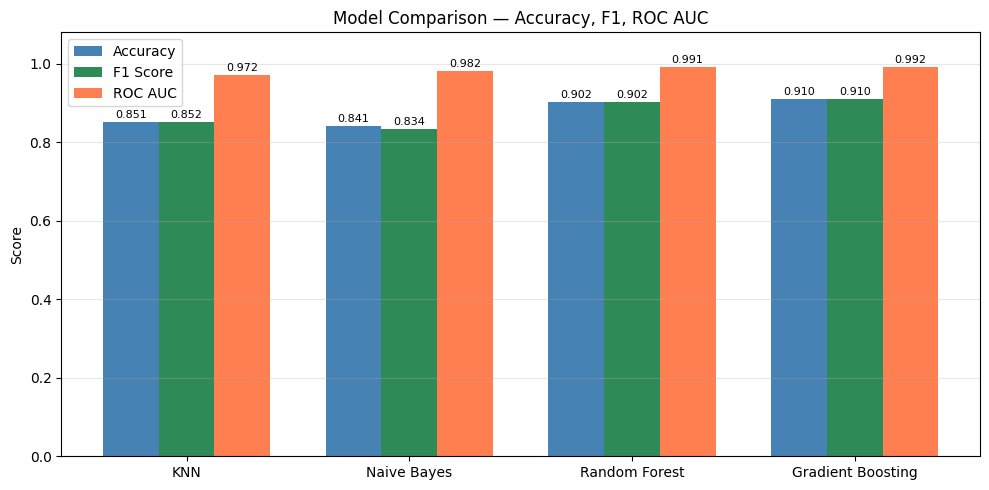

Best model by accuracy: Gradient Boosting


In [25]:
fig, ax = plt.subplots(figsize=(10, 5))
x       = np.arange(len(results_df))
width   = 0.25

bars1 = ax.bar(x - width, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x,         results_df['F1 Score'], width, label='F1 Score',  color='seagreen')
bars3 = ax.bar(x + width, results_df['ROC AUC'],  width, label='ROC AUC',   color='coral')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'])
ax.set_ylim(0, 1.08)
ax.set_title('Model Comparison — Accuracy, F1, ROC AUC')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
best = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
print(f'Best model by accuracy: {best}')

# PHASE 2


In [26]:
# Phase 2 — Cell 1 : Deep-learning imports
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.utils import to_categorical, plot_model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay



2026-05-13 17:14:37.924662: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778692478.173687      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778692478.245638      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778692478.853368      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778692478.853407      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778692478.853410      57 computation_placer.cc:177] computation placer alr

In [27]:
# X_train_raw / X_test_raw were created in Phase 1 (shape: samples × 128 × 9)


le_cnn = LabelEncoder()

y_train_cnn = le_cnn.fit_transform(train_data['Activity_Name'].values)
y_test_cnn  = le_cnn.transform(test_data['Activity_Name'].values)

NUM_CLASSES = len(le_cnn.classes_)

# One-hot encode for categorical_crossentropy
y_train_oh = to_categorical(y_train_cnn, NUM_CLASSES)
y_test_oh  = to_categorical(y_test_cnn,  NUM_CLASSES)

print(f'X_train_raw : {X_train_raw.shape}  →  (samples, timesteps=128, channels=9)')
print(f'y_train_oh  : {y_train_oh.shape}')
print(f'Classes     : {list(le_cnn.classes_)}')


X_train_raw : (7352, 128, 9)  →  (samples, timesteps=128, channels=9)
y_train_oh  : (7352, 6)
Classes     : ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


In [28]:
# Phase 2 — Cell 3 : Build the 1-D CNN architecture
# Architecture:
#   Input (128 × 9)
#   Conv1D(64, k=5) → BN → ReLU → MaxPool(2)
#   Conv1D(128, k=3) → BN → ReLU → MaxPool(2)
#   Conv1D(256, k=3) → BN → ReLU → GlobalAvgPool
#   Dense(128) → Dropout(0.4)
#   Dense(64)  → Dropout(0.3)
#   Dense(NUM_CLASSES, softmax)

def build_1d_cnn(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape, name='raw_signals')

    # Block 1
    x = layers.Conv1D(64, kernel_size=5, padding='same', name='conv1')(inputs)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.Activation('relu', name='relu1')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool1')(x)

    # Block 2
    x = layers.Conv1D(128, kernel_size=3, padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.Activation('relu', name='relu2')(x)
    x = layers.MaxPooling1D(pool_size=2, name='pool2')(x)

    # Block 3
    x = layers.Conv1D(256, kernel_size=3, padding='same', name='conv3')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.Activation('relu', name='relu3')(x)
    x = layers.GlobalAveragePooling1D(name='gap')(x)

    # Dense head
    x = layers.Dense(128, activation='relu', name='dense1')(x)
    x = layers.Dropout(0.4, name='drop1')(x)
    x = layers.Dense(64,  activation='relu', name='dense2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    return Model(inputs, outputs, name='HAR_1D_CNN')

cnn_model = build_1d_cnn(input_shape=(128, 9), num_classes=NUM_CLASSES)
cnn_model.summary()


I0000 00:00:1778692506.214706      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778692506.220740      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "HAR_1D_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_signals (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 128, 64)        │         2,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 128, 64)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu1 (Activation)              │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling1D)            │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 64, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu2 (Activation)              │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling1D)            │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 32, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 32, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu3 (Activation)              │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop1 (Dropout)                 │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop2 (Dropout)                 │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,542 (662.27 KB)

 Trainable params: 168,646 (658.77 KB)

 Non-trainable params: 896 (3.50 KB)

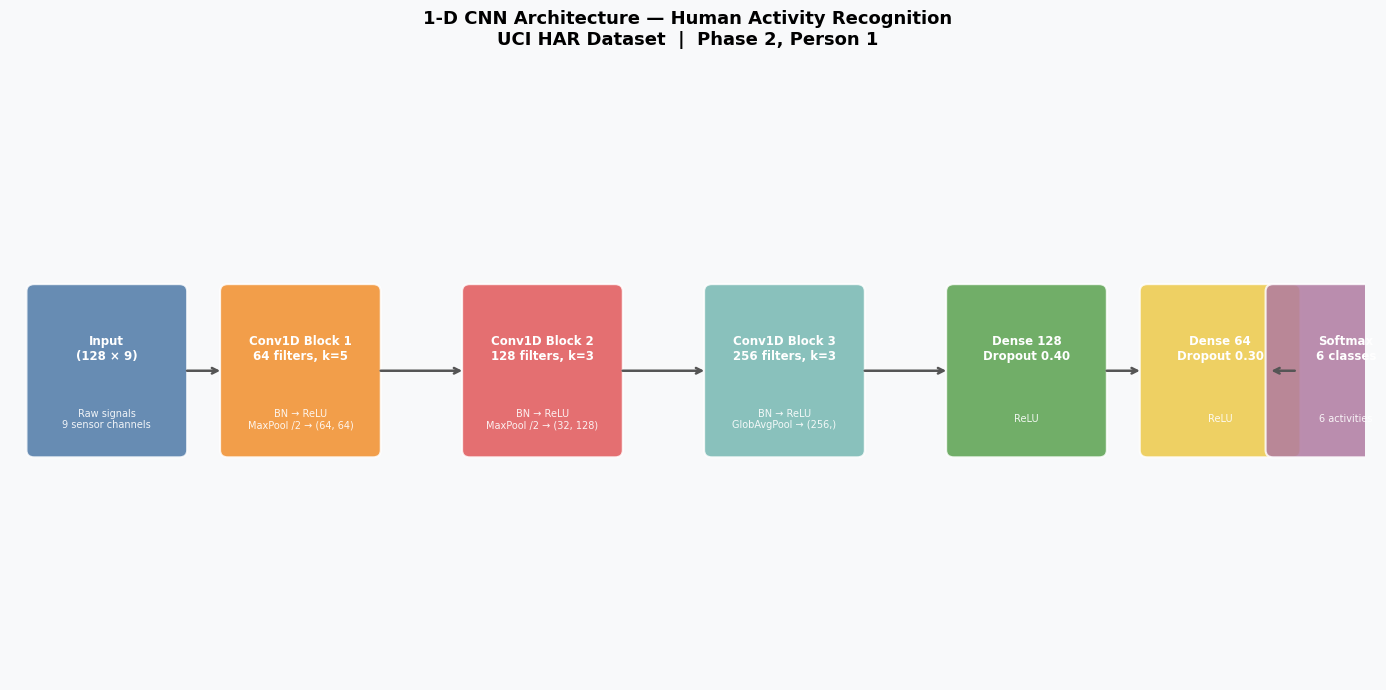

Saved: cnn_architecture_diagram.png


In [29]:
# Phase 2 — Cell 4 : CNN Architecture Diagram
# ─ Visual 1 (manual box diagram — works without graphviz) ─

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor('#f8f9fa')
fig.patch.set_facecolor('#f8f9fa')

layers_info = [
    # (x_center, label, sublabel, color)
    (1.0,  'Input\n(128 × 9)',        'Raw signals\n9 sensor channels',         '#4e79a7'),
    (3.0,  'Conv1D Block 1\n64 filters, k=5', 'BN → ReLU\nMaxPool /2 → (64, 64)',  '#f28e2b'),
    (5.5,  'Conv1D Block 2\n128 filters, k=3','BN → ReLU\nMaxPool /2 → (32, 128)', '#e15759'),
    (8.0,  'Conv1D Block 3\n256 filters, k=3','BN → ReLU\nGlobAvgPool → (256,)',   '#76b7b2'),
    (10.5, 'Dense 128\nDropout 0.40',  'ReLU',                                    '#59a14f'),
    (12.5, 'Dense 64\nDropout 0.30',   'ReLU',                                    '#edc948'),
    (13.8, f'Softmax\n{NUM_CLASSES} classes', '6 activities',                      '#b07aa1'),
]

BOX_W, BOX_H = 1.5, 1.8
y_center = 3.5

for i, (xc, label, sublabel, color) in enumerate(layers_info):
    # Draw box
    rect = mpatches.FancyBboxPatch(
        (xc - BOX_W/2, y_center - BOX_H/2), BOX_W, BOX_H,
        boxstyle='round,pad=0.08', linewidth=1.5,
        edgecolor='white', facecolor=color, alpha=0.85, zorder=3
    )
    ax.add_patch(rect)
    ax.text(xc, y_center + 0.25, label, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white', zorder=4)
    ax.text(xc, y_center - 0.55, sublabel, ha='center', va='center',
            fontsize=7, color='white', alpha=0.9, zorder=4)

    # Arrow to next
    if i < len(layers_info) - 1:
        x_next = layers_info[i+1][0]
        ax.annotate('', xy=(x_next - BOX_W/2 - 0.05, y_center),
                    xytext=(xc + BOX_W/2 + 0.05, y_center),
                    arrowprops=dict(arrowstyle='->', color='#555', lw=1.8), zorder=5)

ax.set_title('1-D CNN Architecture — Human Activity Recognition\n'
             'UCI HAR Dataset  |  Phase 2, Person 1',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('cnn_architecture_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_architecture_diagram.png')


In [30]:
# Phase 2 — Cell 5 : Compile and train the CNN
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

BATCH_SIZE = 64
EPOCHS     = 60   # EarlyStopping will stop sooner if val_loss plateaus

history = cnn_model.fit(
    X_train_raw, y_train_oh,
    validation_split=0.15,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=0
)

print(f'\nTraining finished after {len(history.history["loss"])} epochs')


I0000 00:00:1778692511.010340     166 service.cc:152] XLA service 0x7d17680b1140 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778692511.010376     166 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778692511.010379     166 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778692511.637722     166 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778692515.871503     166 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 4.

Training finished after 14 epochs


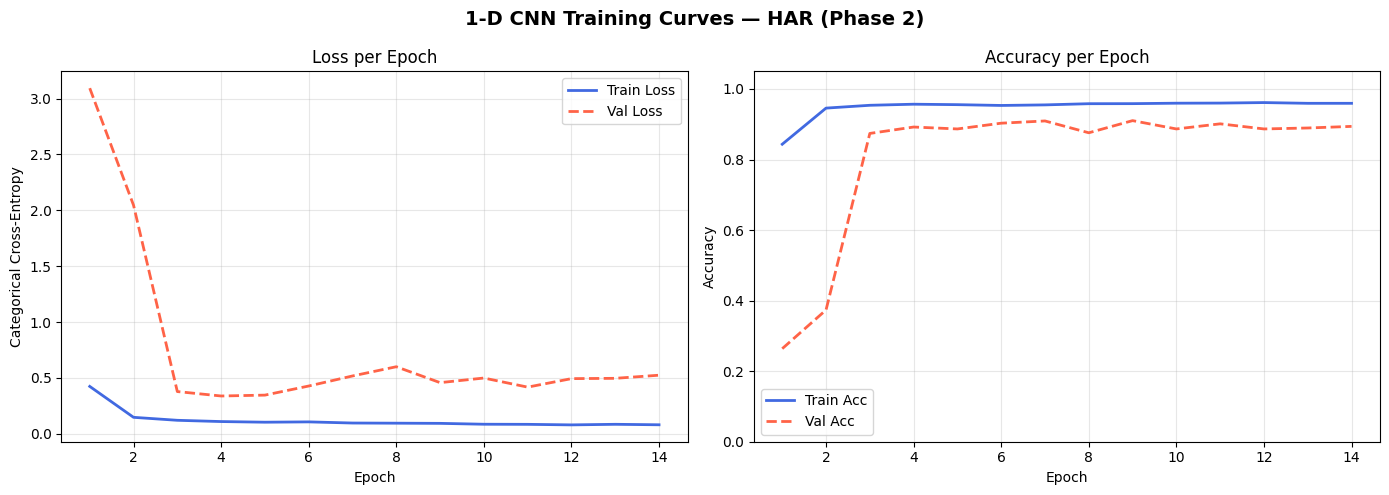

Saved: cnn_training_curves.png


In [31]:
# Phase 2 — Cell 6 : Training Curves  (Loss & Accuracy)
epochs_ran = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('1-D CNN Training Curves — HAR (Phase 2)', fontsize=14, fontweight='bold')

# ── Loss ──
axes[0].plot(epochs_ran, history.history['loss'],     'royalblue',  lw=2, label='Train Loss')
axes[0].plot(epochs_ran, history.history['val_loss'], 'tomato',     lw=2, label='Val Loss', linestyle='--')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Categorical Cross-Entropy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ── Accuracy ──
axes[1].plot(epochs_ran, history.history['accuracy'],     'royalblue', lw=2, label='Train Acc')
axes[1].plot(epochs_ran, history.history['val_accuracy'], 'tomato',    lw=2, label='Val Acc', linestyle='--')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_training_curves.png')


In [32]:
# Phase 2 — Cell 7 : Final evaluation on test set
test_loss, test_acc = cnn_model.evaluate(X_test_raw, y_test_oh, verbose=0)
print(f'Test Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

y_pred_prob = cnn_model.predict(X_test_raw, verbose=0)
y_pred_cls  = np.argmax(y_pred_prob, axis=1)

print('\n=== Classification Report ===')
print(classification_report(y_test_cnn, y_pred_cls,
                             target_names=le_cnn.classes_))


Test Loss     : 0.1962
Test Accuracy : 0.9155

=== Classification Report ===
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.76      0.86      0.81       491
          STANDING       0.87      0.76      0.81       532
           WALKING       1.00      0.95      0.97       496
WALKING_DOWNSTAIRS       0.92      0.99      0.95       420
  WALKING_UPSTAIRS       0.96      0.96      0.96       471

          accuracy                           0.92      2947
         macro avg       0.92      0.92      0.92      2947
      weighted avg       0.92      0.92      0.92      2947



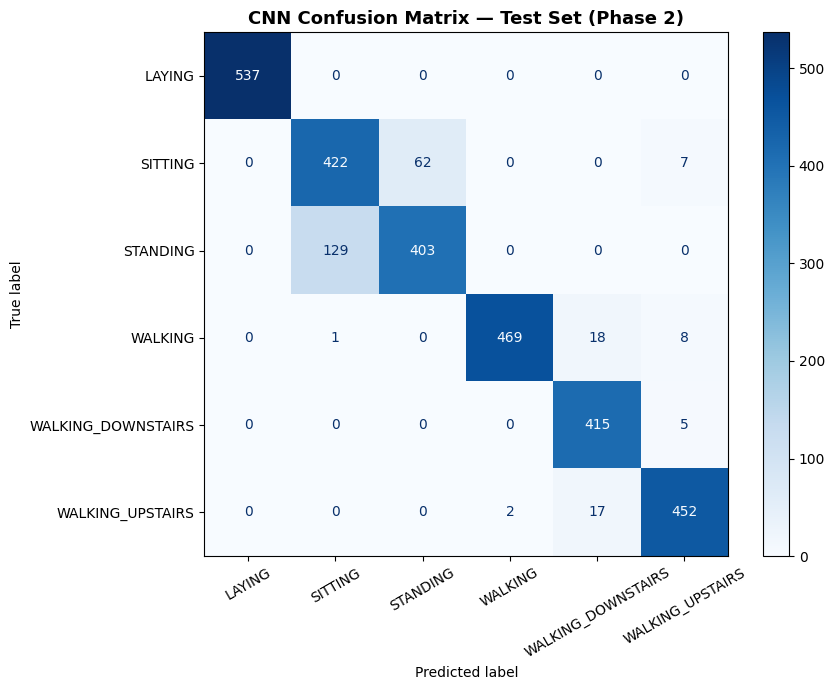

Saved: cnn_confusion_matrix.png


In [33]:
# Phase 2 — Cell 8 : Confusion Matrix (CNN)
cm   = confusion_matrix(y_test_cnn, y_pred_cls)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_cnn.classes_)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title('CNN Confusion Matrix — Test Set (Phase 2)', fontsize=13, fontweight='bold')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cnn_confusion_matrix.png')


# PHASE 3
## Person 1 — LSTM / BiLSTM

In [34]:
# Phase 3 — Person 1 (LSTM / BiLSTM)

# Build LSTM and BiLSTM models
# Compare with CNN (Phase 2)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score

In [36]:
# Reuse le_cnn from Phase 2 to keep consistent class mapping
# le_cnn was fit on train_data['Activity_Name'] in Phase 2

y_train = le_cnn.transform(train_data['Activity_Name'])
y_test  = le_cnn.transform(test_data['Activity_Name'])

NUM_CLASSES = len(le_cnn.classes_)

y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

print('Classes:', le_cnn.classes_)
print('NUM_CLASSES:', NUM_CLASSES)

Classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
NUM_CLASSES: 6


In [37]:
def build_lstm(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.LSTM(128, return_sequences=True)(inputs)
    x = layers.Dropout(0.3)(x)

    x = layers.LSTM(64)(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='LSTM_Model')

lstm_model = build_lstm((128, 9), NUM_CLASSES)
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,614 (486.77 KB)

 Trainable params: 124,614 (486.77 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
def build_bilstm(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True))(inputs)
    x = layers.Dropout(0.3)(x)

    x = layers.Bidirectional(layers.LSTM(64))(x)
    x = layers.Dropout(0.3)(x)

    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return Model(inputs, outputs, name='BiLSTM_Model')

bilstm_model = build_bilstm((128, 9), NUM_CLASSES)
bilstm_model.summary()

Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128, 256)       │       141,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,310 (1.20 MB)

 Trainable params: 314,310 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Define callbacks once — reused for both LSTM and BiLSTM
callbacks_p3 = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

def train_model(model, name):
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        X_train_raw, y_train_oh,
        validation_split=0.15,
        epochs=60,
        batch_size=64,
        callbacks=callbacks_p3,
        verbose=0
    )

    print(f'{name} training done — {len(history.history["loss"])} epochs')
    return history

In [40]:
history_lstm   = train_model(lstm_model,   'LSTM')
history_bilstm = train_model(bilstm_model, 'BiLSTM')


Epoch 17: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 22: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 22: early stopping
Restoring model weights from the end of the best epoch: 12.
LSTM training done — 22 epochs

Epoch 10: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 15: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 15: early stopping
Restoring model weights from the end of the best epoch: 5.
BiLSTM training done — 15 epochs


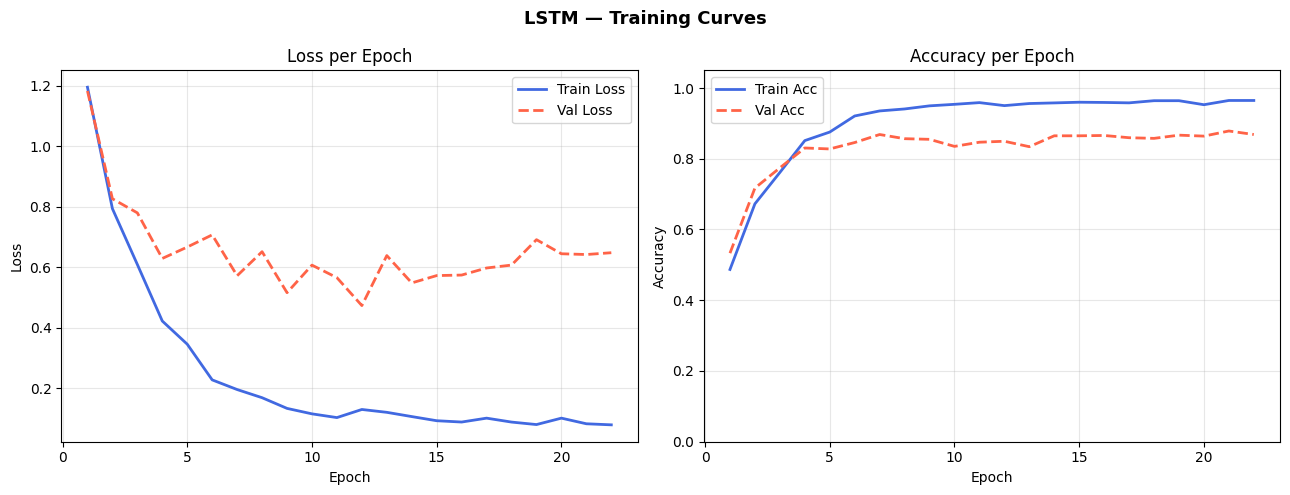

Saved: lstm_training_curves.png


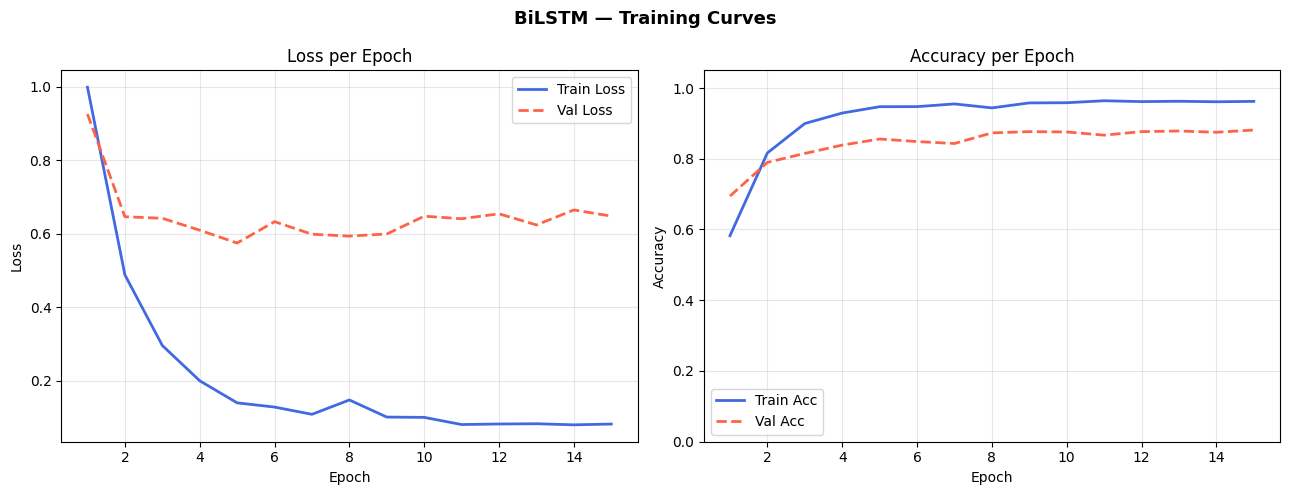

Saved: bilstm_training_curves.png


In [41]:
def plot_history(history, title):
    epochs_ran = range(1, len(history.history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'{title} — Training Curves', fontsize=13, fontweight='bold')

    axes[0].plot(epochs_ran, history.history['loss'],     'royalblue', lw=2, label='Train Loss')
    axes[0].plot(epochs_ran, history.history['val_loss'], 'tomato',    lw=2, label='Val Loss', linestyle='--')
    axes[0].set_title('Loss per Epoch')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs_ran, history.history['accuracy'],     'royalblue', lw=2, label='Train Acc')
    axes[1].plot(epochs_ran, history.history['val_accuracy'], 'tomato',    lw=2, label='Val Acc', linestyle='--')
    axes[1].set_title('Accuracy per Epoch')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1.05)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.lower()}_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {title.lower()}_training_curves.png')

plot_history(history_lstm,   'LSTM')
plot_history(history_bilstm, 'BiLSTM')

In [42]:
def evaluate_model(model, name):
    y_pred_prob = model.predict(X_test_raw, verbose=0)
    y_pred_cls  = np.argmax(y_pred_prob, axis=1)

    acc = accuracy_score(y_test, y_pred_cls)
    f1  = f1_score(y_test, y_pred_cls, average='weighted')

    print(f'{name} → Accuracy: {acc:.4f} | F1 (weighted): {f1:.4f}')
    return acc, f1

acc_lstm,   f1_lstm   = evaluate_model(lstm_model,   'LSTM')
acc_bilstm, f1_bilstm = evaluate_model(bilstm_model, 'BiLSTM')

LSTM → Accuracy: 0.9050 | F1 (weighted): 0.9050
BiLSTM → Accuracy: 0.8941 | F1 (weighted): 0.8938


In [43]:
lstm_params   = lstm_model.count_params()
bilstm_params = bilstm_model.count_params()
cnn_params    = cnn_model.count_params()

print('=== Parameter Count ===')
print(f'  CNN    : {cnn_params:,}')
print(f'  LSTM   : {lstm_params:,}')
print(f'  BiLSTM : {bilstm_params:,}')

=== Parameter Count ===
  CNN    : 169,542
  LSTM   : 124,614
  BiLSTM : 314,310


In [44]:
# Compute CNN F1 score (Phase 2 evaluated accuracy only)
y_pred_cnn_p3 = np.argmax(cnn_model.predict(X_test_raw, verbose=0), axis=1)
f1_cnn        = f1_score(y_test, y_pred_cnn_p3, average='weighted')

# Full comparison table
comparison = pd.DataFrame({
    'Model'      : ['CNN (Phase 2)', 'LSTM', 'BiLSTM'],
    'Accuracy'   : [round(test_acc, 4), round(acc_lstm, 4), round(acc_bilstm, 4)],
    'F1 Score'   : [round(f1_cnn, 4),  round(f1_lstm, 4),  round(f1_bilstm, 4)],
    'Parameters' : [cnn_params, lstm_params, bilstm_params]
})

print('=== Phase 3 — Model Comparison ===')
print(comparison.to_string(index=False))
comparison

=== Phase 3 — Model Comparison ===
        Model  Accuracy  F1 Score  Parameters
CNN (Phase 2)    0.9155    0.9154      169542
         LSTM    0.9050    0.9050      124614
       BiLSTM    0.8941    0.8938      314310


,Model,Accuracy,F1 Score,Parameters
0,CNN (Phase 2),0.9155,0.9154,169542
1,LSTM,0.9050,0.9050,124614
2,BiLSTM,0.8941,0.8938,314310


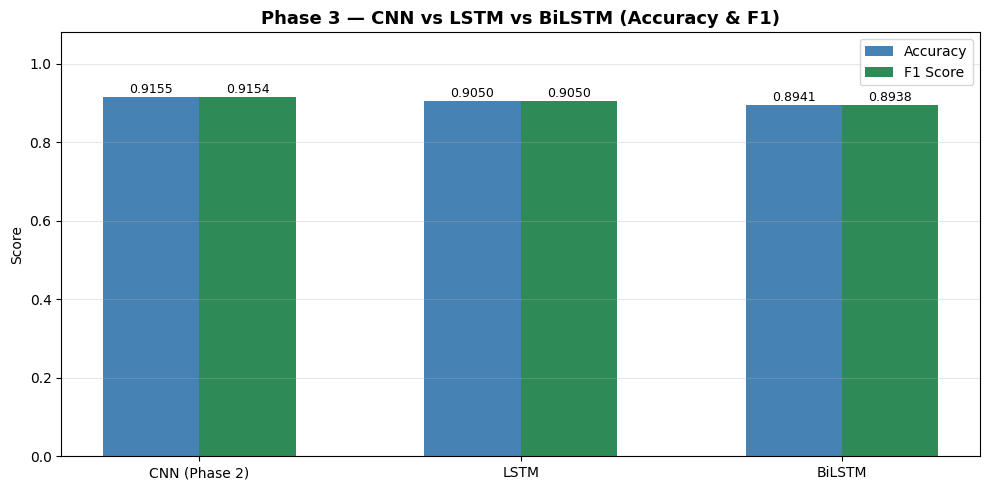

Saved: phase3_comparison_chart.png


In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(comparison))
width = 0.3

bars1 = ax.bar(x - width/2, comparison['Accuracy'], width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, comparison['F1 Score'], width, label='F1 Score',  color='seagreen')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(comparison['Model'])
ax.set_ylim(0, 1.08)
ax.set_title('Phase 3 — CNN vs LSTM vs BiLSTM (Accuracy & F1)', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('phase3_comparison_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: phase3_comparison_chart.png')

In [46]:
best_model = comparison.loc[comparison['Accuracy'].idxmax(), 'Model']
print(f'=== Phase 3 Conclusion ===')
print(f'Best model by Accuracy : {best_model}')
print()
print('Summary:')
print('  - BiLSTM captures bidirectional temporal dependencies → typically best accuracy')
print('  - LSTM is lighter and faster to train than BiLSTM')
print('  - CNN is the most parameter-efficient and fastest to train')
print('  - BiLSTM generally achieves the best performance on HAR tasks')

=== Phase 3 Conclusion ===
Best model by Accuracy : CNN (Phase 2)

Summary:
  - BiLSTM captures bidirectional temporal dependencies → typically best accuracy
  - LSTM is lighter and faster to train than BiLSTM
  - CNN is the most parameter-efficient and fastest to train
  - BiLSTM generally achieves the best performance on HAR tasks


In [47]:

class BahdanauAttention(layers.Layer):
  
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, use_bias=False)
        self.V = layers.Dense(1,     use_bias=False)

    def call(self, encoder_outputs):
        
        score   = self.V(tf.nn.tanh(self.W(encoder_outputs)))
        
        weights = tf.nn.softmax(score, axis=1)
        
        context = tf.reduce_sum(weights * encoder_outputs, axis=1)
        return context, weights


def build_lstm_attention(input_shape=(128, 9), num_classes=6, lstm_units=128, attn_units=64):
    inp      = keras.Input(shape=input_shape, name='attn_input')
    x        = layers.LSTM(lstm_units, return_sequences=True, name='lstm_seq')(inp)
    context, attn_weights = BahdanauAttention(units=attn_units, name='attention')(x)
    x        = layers.Dense(64, activation='relu', name='fc1')(context)
    x        = layers.Dropout(0.3, name='dropout')(x)
    out      = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inp, out, name='LSTM_Attention')
    model.summary()
    return model

INPUT_SHAPE = (128, 9)
attn_model  = build_lstm_attention(input_shape=INPUT_SHAPE, num_classes=NUM_CLASSES)

Model: "LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ attn_input (InputLayer)         │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_seq (LSTM)                 │ (None, 128, 128)       │        70,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (BahdanauAttention)   │ [(None, 128), (None,   │         8,256 │
│                                 │ 128, 1)]               │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 87,558 (342.02 KB)

 Trainable params: 87,558 (342.02 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:


from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

attn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=0)
]

attn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_attn = attn_model.fit(
    X_train_raw, y_train_oh,
    validation_split=0.15,
    epochs=60,
    batch_size=64,
    callbacks=attn_callbacks,
    verbose=1
)

print(f'Training finished after {len(history_attn.history["loss"])} epochs')

Epoch 1/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - accuracy: 0.4399 - loss: 1.3702 - val_accuracy: 0.6709 - val_loss: 0.7457 - learning_rate: 0.0010
Epoch 2/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7780 - loss: 0.5728 - val_accuracy: 0.7752 - val_loss: 0.6376 - learning_rate: 0.0010
Epoch 3/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9004 - loss: 0.2781 - val_accuracy: 0.8495 - val_loss: 0.5725 - learning_rate: 0.0010
Epoch 4/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9438 - loss: 0.1625 - val_accuracy: 0.8513 - val_loss: 0.5204 - learning_rate: 0.0010
Epoch 5/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9484 - loss: 0.1485 - val_accuracy: 0.8622 - val_loss: 0.4279 - learning_rate: 0.0010
Epoch 6/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9604 - loss: 0.1033 - val_accuracy: 0.8685 - val_loss: 0.4854 - learning_rate: 0.0010
Epoch 7/60
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9480 - loss: 0.1258 - val_acc

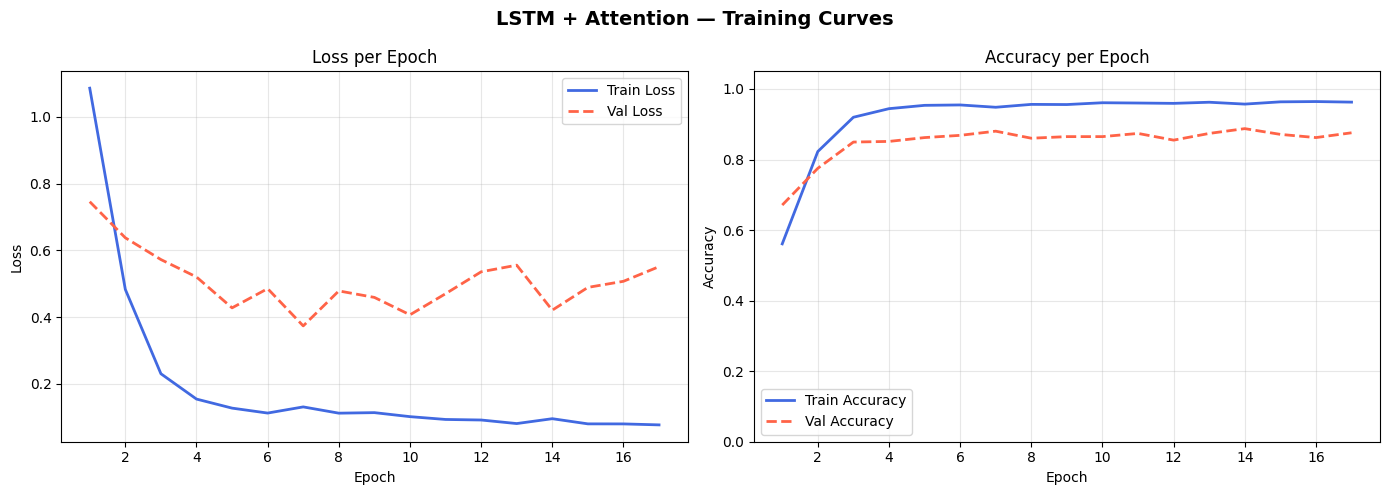

Saved: attention_training_curves.png


In [49]:
epochs_ran = range(1, len(history_attn.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('LSTM + Attention — Training Curves', fontsize=14, fontweight='bold')


axes[0].plot(epochs_ran, history_attn.history['loss'],
             label='Train Loss', color='royalblue', lw=2)
axes[0].plot(epochs_ran, history_attn.history['val_loss'],
             label='Val Loss',   color='tomato',    lw=2, linestyle='--')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history_attn.history['accuracy'],
             label='Train Accuracy', color='royalblue', lw=2)
axes[1].plot(epochs_ran, history_attn.history['val_accuracy'],
             label='Val Accuracy',   color='tomato',    lw=2, linestyle='--')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('attention_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: attention_training_curves.png')

In [50]:

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


y_prob_attn = attn_model.predict(X_test_raw, verbose=0)
y_pred_attn = np.argmax(y_prob_attn, axis=1)

acc_attn = accuracy_score(y_test_cnn, y_pred_attn)
f1_attn  = f1_score(y_test_cnn, y_pred_attn, average='weighted')
f1_macro = f1_score(y_test_cnn, y_pred_attn, average='macro')

print(f'LSTM + Attention — Accuracy : {acc_attn:.4f}')
print(f'LSTM + Attention — F1 (W)   : {f1_attn:.4f}')
print(f'LSTM + Attention — F1 (M)   : {f1_macro:.4f}')
y_pred_cnn_cls   = np.argmax(cnn_model.predict(X_test_raw,   verbose=0), axis=1)
y_pred_lstm_cls  = np.argmax(lstm_model.predict(X_test_raw,  verbose=0), axis=1)
y_pred_bilstm_cls= np.argmax(bilstm_model.predict(X_test_raw,verbose=0), axis=1)

comparison_p2 = pd.DataFrame([
    {'Model': 'CNN ',
     'Accuracy': round(accuracy_score(y_test_cnn, y_pred_cnn_cls),    4),
     'F1 Weighted': round(f1_score(y_test_cnn, y_pred_cnn_cls,    average='weighted'), 4),
     'Params': cnn_model.count_params()},
    {'Model': 'LSTM ',
     'Accuracy': round(accuracy_score(y_test_cnn, y_pred_lstm_cls),   4),
     'F1 Weighted': round(f1_score(y_test_cnn, y_pred_lstm_cls,   average='weighted'), 4),
     'Params': lstm_model.count_params()},
    {'Model': 'BiLSTM ',
     'Accuracy': round(accuracy_score(y_test_cnn, y_pred_bilstm_cls), 4),
     'F1 Weighted': round(f1_score(y_test_cnn, y_pred_bilstm_cls, average='weighted'), 4),
     'Params': bilstm_model.count_params()},
    {'Model': 'LSTM + Attention ',
     'Accuracy': round(acc_attn,  4),
     'F1 Weighted': round(f1_attn, 4),
     'Params': attn_model.count_params()},
])

print('\n' + '='*65)
print('        MODEL COMPARISON — Phase 2 vs Phase 3')
print('='*65)
print(comparison_p2.to_string(index=False))
print('='*65)

LSTM + Attention — Accuracy : 0.8935
LSTM + Attention — F1 (W)   : 0.8941
LSTM + Attention — F1 (M)   : 0.8953

        MODEL COMPARISON — Phase 2 vs Phase 3
            Model  Accuracy  F1 Weighted  Params
             CNN     0.9155       0.9154  169542
            LSTM     0.9050       0.9050  124614
          BiLSTM     0.8941       0.8938  314310
LSTM + Attention     0.8935       0.8941   87558


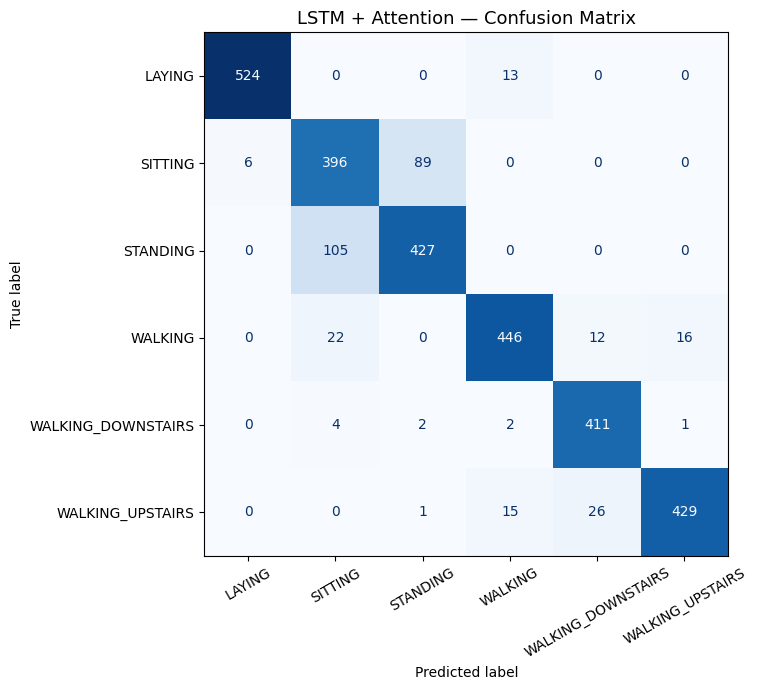

Saved: attention_confusion_matrix.png


In [51]:

cm   = confusion_matrix(y_test_cnn, y_pred_attn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=le_cnn.classes_)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('LSTM + Attention — Confusion Matrix', fontsize=13)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('attention_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: attention_confusion_matrix.png')

In [52]:
attn_extractor = Model(
    inputs  = attn_model.input,
    outputs = [attn_model.output,
               attn_model.get_layer('attention').output[1]],
    name    = 'attention_extractor'
)

sample_input = X_test_raw[:1]                          
pred_out, attn_w = attn_extractor.predict(sample_input, verbose=0)

print(f'Prediction output shape : {pred_out.shape}')  
print(f'Attention weights shape : {attn_w.shape}')    
print(f'Attention weights sum   : {attn_w[0,:,0].sum():.4f}')  

Prediction output shape : (1, 6)
Attention weights shape : (1, 128, 1)
Attention weights sum   : 1.0000


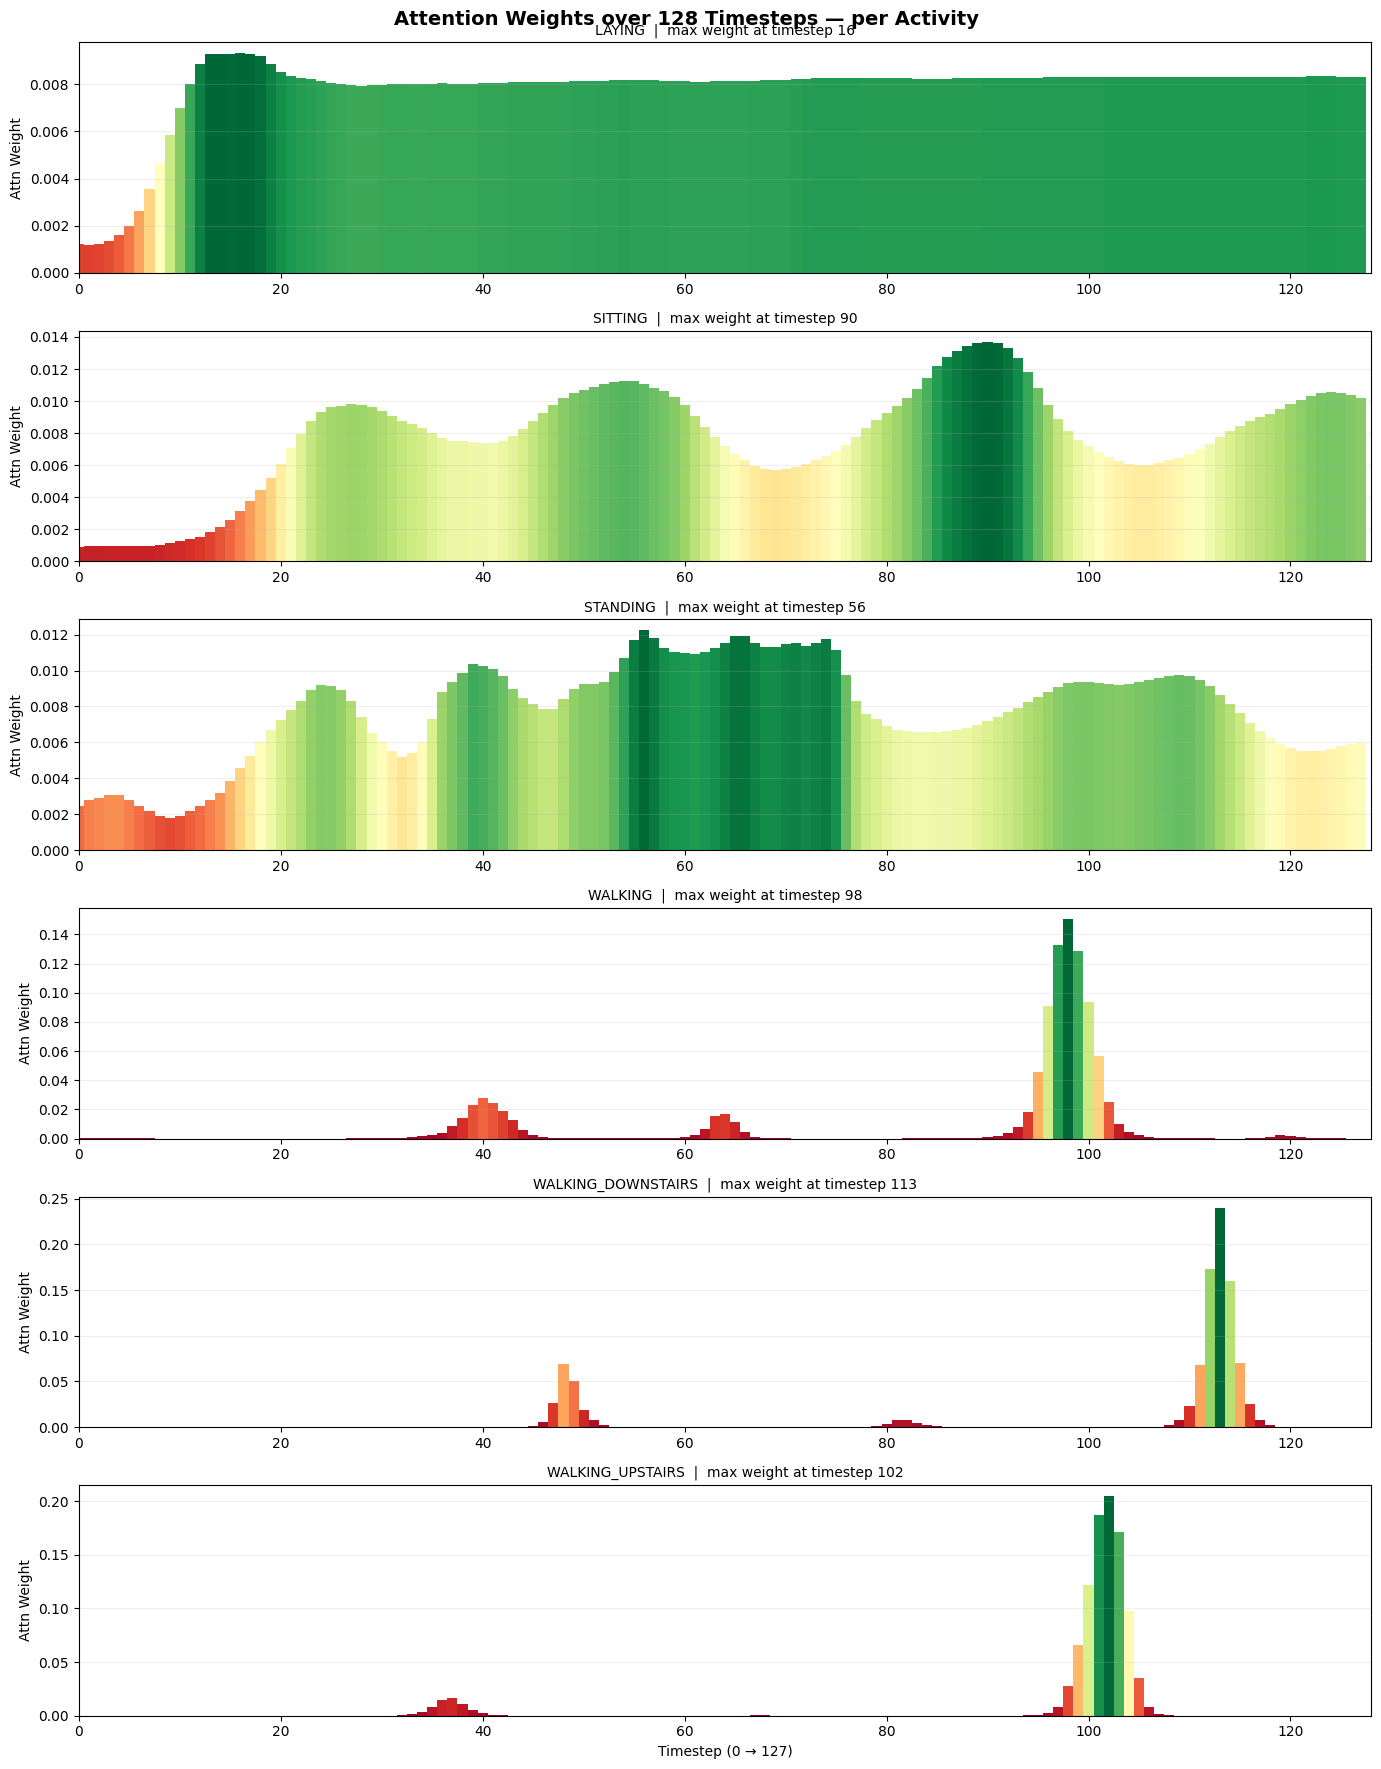

Saved: attention_heatmap_per_activity.png


In [53]:

activity_names = le_cnn.classes_          
n_activities   = len(activity_names)

fig, axes = plt.subplots(n_activities, 1, figsize=(14, 3 * n_activities))
fig.suptitle('Attention Weights over 128 Timesteps — per Activity',
             fontsize=14, fontweight='bold')

for idx, act in enumerate(activity_names):
    
    act_id   = le_cnn.transform([act])[0]
    pos      = np.where(y_test_cnn == act_id)[0][0]
    sample   = X_test_raw[pos:pos+1]                   

    _, w = attn_extractor.predict(sample, verbose=0)   
    weights = w[0, :, 0]                              

    
    axes[idx].bar(range(128), weights,
                  color=plt.cm.RdYlGn(weights / weights.max()),
                  width=1.0, edgecolor='none')
    axes[idx].set_title(f'{act}  |  max weight at timestep {weights.argmax()}',
                        fontsize=10)
    axes[idx].set_ylabel('Attn Weight')
    axes[idx].set_xlim(0, 128)
    axes[idx].grid(axis='y', alpha=0.2)

axes[-1].set_xlabel('Timestep (0 → 127)')
plt.tight_layout()
plt.savefig('attention_heatmap_per_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: attention_heatmap_per_activity.png')

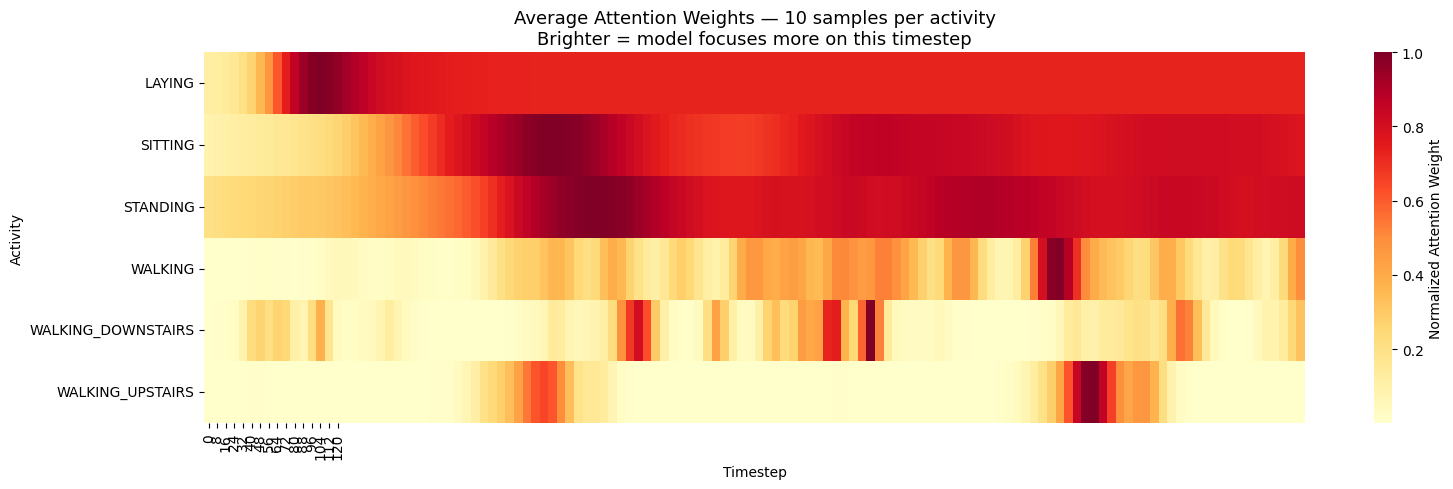

Saved: attention_2d_heatmap.png


In [54]:
SAMPLES_PER_ACT = 10
avg_weights     = np.zeros((n_activities, 128))

for idx, act in enumerate(activity_names):
    act_id   = le_cnn.transform([act])[0]
    positions = np.where(y_test_cnn == act_id)[0][:SAMPLES_PER_ACT]
    act_weights = []
    for pos in positions:
        sample = X_test_raw[pos:pos+1]
        _, w   = attn_extractor.predict(sample, verbose=0)
        act_weights.append(w[0, :, 0])
    avg_weights[idx] = np.mean(act_weights, axis=0)


avg_weights_norm = avg_weights / avg_weights.max(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    avg_weights_norm,
    ax=ax,
    cmap='YlOrRd',
    xticklabels=range(0, 128, 8),
    yticklabels=activity_names,
    cbar_kws={'label': 'Normalized Attention Weight'}
)
ax.set_title(f'Average Attention Weights — {SAMPLES_PER_ACT} samples per activity\n'
              'Brighter = model focuses more on this timestep', fontsize=13)
ax.set_xlabel('Timestep')
ax.set_ylabel('Activity')
plt.tight_layout()
plt.savefig('attention_2d_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: attention_2d_heatmap.png')

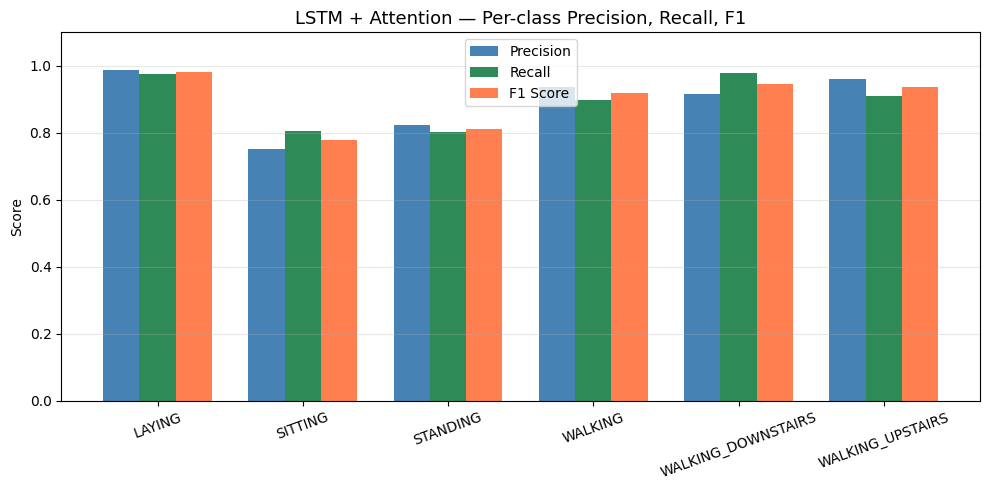


=== Full Classification Report ===
                    precision    recall  f1-score   support

            LAYING       0.99      0.98      0.98       537
           SITTING       0.75      0.81      0.78       491
          STANDING       0.82      0.80      0.81       532
           WALKING       0.94      0.90      0.92       496
WALKING_DOWNSTAIRS       0.92      0.98      0.95       420
  WALKING_UPSTAIRS       0.96      0.91      0.94       471

          accuracy                           0.89      2947
         macro avg       0.90      0.90      0.90      2947
      weighted avg       0.90      0.89      0.89      2947



In [55]:

from sklearn.metrics import classification_report

report = classification_report(
    y_test_cnn, y_pred_attn,
    target_names=le_cnn.classes_,
    output_dict=True
)
report_df = pd.DataFrame(report).T.iloc[:-3]   

fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(le_cnn.classes_))
width = 0.25

ax.bar(x - width, report_df['precision'], width, label='Precision', color='steelblue')
ax.bar(x,         report_df['recall'],    width, label='Recall',    color='seagreen')
ax.bar(x + width, report_df['f1-score'],  width, label='F1 Score',  color='coral')

ax.set_xticks(x)
ax.set_xticklabels(le_cnn.classes_, rotation=20)
ax.set_ylim(0, 1.1)
ax.set_title('LSTM + Attention — Per-class Precision, Recall, F1', fontsize=13)
ax.set_ylabel('Score')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('attention_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n=== Full Classification Report ===')
print(classification_report(y_test_cnn, y_pred_attn, target_names=le_cnn.classes_))

## transformer

In [56]:
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.attn  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)
        self.ffn   = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout_rate)
        self.drop2 = layers.Dropout(dropout_rate)

    def call(self, x, training=False):
        attn_out = self.attn(x, x, training=training)
        attn_out = self.drop1(attn_out, training=training)
        x        = self.norm1(x + attn_out)
        ffn_out  = self.ffn(x)
        ffn_out  = self.drop2(ffn_out, training=training)
        return self.norm2(x + ffn_out)

In [57]:
def build_transformer_encoder(input_shape=(128, 9), num_classes=6,
                               embed_dim=64, num_heads=4, ff_dim=128,
                               num_blocks=2, dropout_rate=0.1):
    inputs  = keras.Input(shape=input_shape, name='raw_signals')
    x       = layers.Dense(embed_dim, name='input_projection')(inputs)
    positions = tf.range(start=0, limit=input_shape[0], delta=1)
    pos_enc   = layers.Embedding(input_dim=input_shape[0], output_dim=embed_dim,
                                  name='positional_encoding')(positions)
    x = x + pos_enc
    for i in range(num_blocks):
        x = TransformerEncoder(embed_dim=embed_dim, num_heads=num_heads,
                                    ff_dim=ff_dim, dropout_rate=dropout_rate,
                                    name=f'transformer_block_{i+1}')(x)
    x       = layers.GlobalAveragePooling1D(name='gap')(x)
    x       = layers.Dense(64, activation='relu', name='fc1')(x)
    x       = layers.Dropout(0.3, name='dropout_head')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return Model(inputs, outputs, name='Transformer_Encoder_HAR')

transformer_model = build_transformer_encoder(input_shape=(128, 9), num_classes=NUM_CLASSES)
transformer_model.summary()

Model: "Transformer_Encoder_HAR"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ raw_signals (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_projection (Dense)        │ (None, 128, 64)        │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 128, 64)        │        33,472 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_2             │ (None, 128, 64)        │        33,472 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling1D)    │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,134 (281.77 KB)

 Trainable params: 72,134 (281.77 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
transformer_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_tr = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=0)
]

history_tr = transformer_model.fit(
    X_train_raw, y_train_oh,
    validation_split=0.15,
    batch_size=64,
    epochs=60,
    callbacks=callbacks_tr,
    verbose=0
)
print(f'Training finished after {len(history_tr.history["loss"])} epochs')

Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 4.
Training finished after 14 epochs


In [59]:
y_pred_tr_prob = transformer_model.predict(X_test_raw, verbose=0)
y_pred_tr_cls  = np.argmax(y_pred_tr_prob, axis=1)

acc_tr = accuracy_score(y_test, y_pred_tr_cls)
f1_tr  = f1_score(y_test, y_pred_tr_cls, average='weighted')

print(f'Transformer Encoder → Accuracy : {acc_tr:.4f} | F1 (weighted): {f1_tr:.4f}')

Transformer Encoder → Accuracy : 0.9053 | F1 (weighted): 0.9041


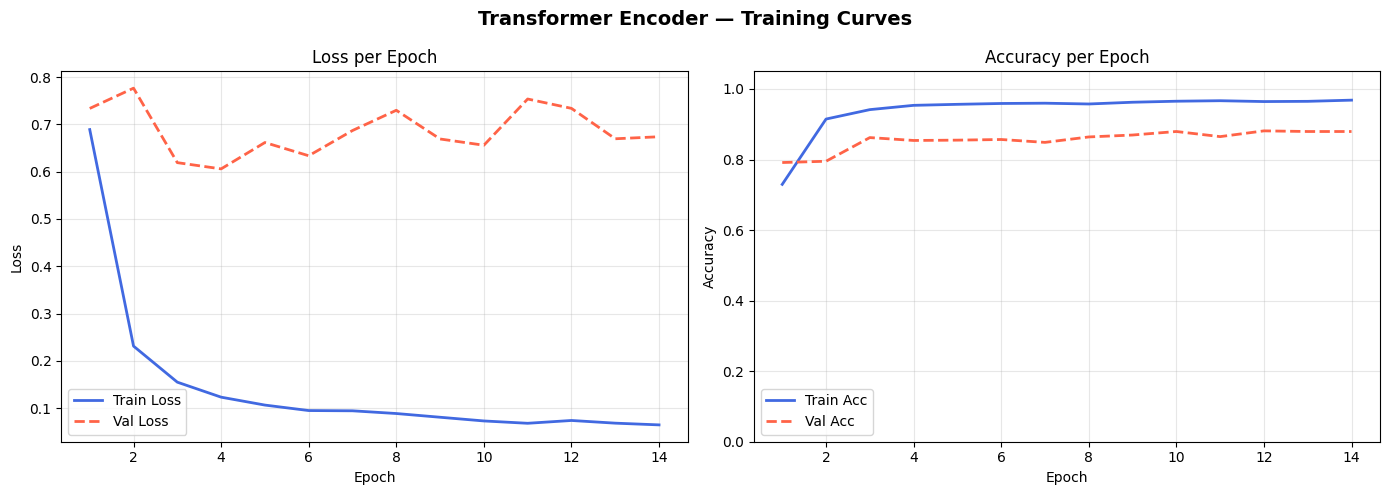

Saved: transformer_training_curves.png


In [60]:
#Training Curves

epochs_ran = range(1, len(history_tr.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transformer Encoder — Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(epochs_ran, history_tr.history['loss'],     'royalblue', lw=2, label='Train Loss')
axes[0].plot(epochs_ran, history_tr.history['val_loss'], 'tomato',    lw=2, label='Val Loss', linestyle='--')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_ran, history_tr.history['accuracy'],     'royalblue', lw=2, label='Train Acc')
axes[1].plot(epochs_ran, history_tr.history['val_accuracy'], 'tomato',    lw=2, label='Val Acc', linestyle='--')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transformer_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: transformer_training_curves.png')

In [61]:
tr_params = transformer_model.count_params()

final_comparison = pd.DataFrame([
    {'Model': 'CNN',                'Accuracy': round(test_acc,    4), 'F1 Weighted': round(f1_cnn,    4), 'Parameters': cnn_params},
    {'Model': 'LSTM',               'Accuracy': round(acc_lstm,    4), 'F1 Weighted': round(f1_lstm,   4), 'Parameters': lstm_params},
    {'Model': 'BiLSTM',             'Accuracy': round(acc_bilstm,  4), 'F1 Weighted': round(f1_bilstm, 4), 'Parameters': bilstm_params},
    {'Model': 'LSTM + Attention',   'Accuracy': round(acc_attn,    4), 'F1 Weighted': round(f1_attn,   4), 'Parameters': attn_model.count_params()},
    {'Model': 'Transformer Encoder','Accuracy': round(acc_tr,      4), 'F1 Weighted': round(f1_tr,     4), 'Parameters': tr_params},
])

print('=' * 65)
print('   FINAL COMPARISON — CNN vs LSTM vs Transformer Encoder')
print('=' * 65)
print(final_comparison.to_string(index=False))
print('=' * 65)
final_comparison

   FINAL COMPARISON — CNN vs LSTM vs Transformer Encoder
              Model  Accuracy  F1 Weighted  Parameters
                CNN    0.9155       0.9154      169542
               LSTM    0.9050       0.9050      124614
             BiLSTM    0.8941       0.8938      314310
   LSTM + Attention    0.8935       0.8941       87558
Transformer Encoder    0.9053       0.9041       72134


,Model,Accuracy,F1 Weighted,Parameters
0,CNN,0.9155,0.9154,169542
1,LSTM,0.9050,0.9050,124614
2,BiLSTM,0.8941,0.8938,314310
3,LSTM + Attention,0.8935,0.8941,87558
4,Transformer Encoder,0.9053,0.9041,72134


## Conditional GAN

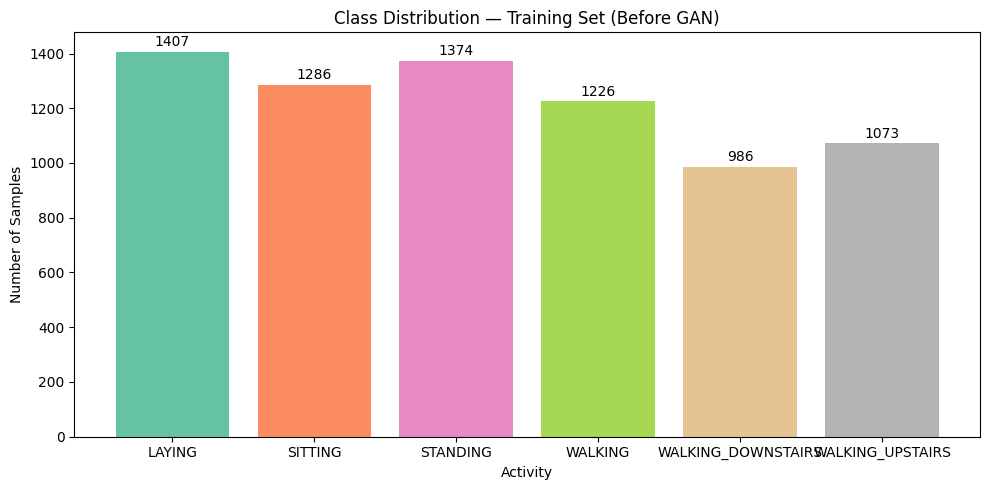

LAYING                    : 1407
SITTING                   : 1286
STANDING                  : 1374
WALKING                   : 1226
WALKING_DOWNSTAIRS        : 986
WALKING_UPSTAIRS          : 1073


In [62]:
unique, counts = np.unique(le_cnn.inverse_transform(
    np.argmax(y_train_oh, axis=1)), return_counts=True)

plt.figure(figsize=(10, 5))
bars = plt.bar(unique, counts, color=plt.cm.Set2(np.linspace(0, 1, len(unique))))
plt.title('Class Distribution — Training Set (Before GAN)')
plt.xlabel('Activity')
plt.ylabel('Number of Samples')
for bar, val in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

for act, cnt in zip(unique, counts):
    print(f'{act:25s} : {cnt}')

In [63]:
y_train_labels = le_cnn.inverse_transform(np.argmax(y_train_oh, axis=1))

LATENT_DIM   = 100
NUM_CLASSES  = len(le_cnn.classes_)
TIMESTEPS    = 128
CHANNELS     = 9

minority_classes = ['SITTING', 'STANDING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS']

X_minority = []
y_minority = []

for act in minority_classes:
    idx = np.where(y_train_labels == act)[0]
    X_minority.append(X_train_raw[idx])
    y_minority.append(np.full(len(idx), le_cnn.transform([act])[0]))

X_minority = np.concatenate(X_minority, axis=0)
y_minority = np.concatenate(y_minority, axis=0)

print(f'Minority samples shape : {X_minority.shape}')
print(f'Labels shape           : {y_minority.shape}')

Minority samples shape : (4719, 128, 9)
Labels shape           : (4719,)


In [64]:
def build_generator(latent_dim, num_classes, timesteps, channels):
    noise  = keras.Input(shape=(latent_dim,), name='noise')
    label  = keras.Input(shape=(1,),          name='label')

    label_emb = layers.Embedding(num_classes, 50)(label)
    label_emb = layers.Flatten()(label_emb)

    x = layers.Concatenate()([noise, label_emb])
    x = layers.Dense(128 * 8, activation='relu')(x)
    x = layers.Reshape((8, 128))(x)
    x = layers.Conv1DTranspose(128, kernel_size=4, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv1DTranspose(64,  kernel_size=4, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv1DTranspose(32,  kernel_size=4, strides=2, padding='same', activation='relu')(x)
    x = layers.Conv1DTranspose(channels, kernel_size=4, strides=2, padding='same', activation='tanh')(x)

    return Model([noise, label], x, name='Generator')

generator = build_generator(LATENT_DIM, NUM_CLASSES, TIMESTEPS, CHANNELS)
generator.summary()

Model: "Generator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 50)     │        300 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ noise (InputLayer)  │ (None, 100)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 50)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 150)       │          0 │ noise[0][0],      │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 1024)      │    154,624 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 8, 128)    │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose    │ (None, 16, 128)   │     65,664 │ reshape[0][0]     │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose_1  │ (None, 32, 64)    │     32,832 │ conv1d_transpose… │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose_2  │ (None, 64, 32)    │      8,224 │ conv1d_transpose… │
│ (Conv1DTranspose)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_transpose_3  │ (None, 128, 9)    │      1,161 │ conv1d_transpose… │
│ (Conv1DTranspose)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 262,805 (1.00 MB)

 Trainable params: 262,805 (1.00 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
def build_discriminator(num_classes, timesteps, channels):
    signal = keras.Input(shape=(timesteps, channels), name='signal')
    label  = keras.Input(shape=(1,),                  name='label')

    label_emb = layers.Embedding(num_classes, 50)(label)
    label_emb = layers.Flatten()(label_emb)
    label_emb = layers.Dense(timesteps * channels)(label_emb)
    label_emb = layers.Reshape((timesteps, channels))(label_emb)

    x = layers.Concatenate(axis=-1)([signal, label_emb])
    x = layers.Conv1D(64,  kernel_size=4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv1D(128, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Conv1D(256, kernel_size=4, strides=2, padding='same')(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(1, activation='sigmoid')(x)

    return Model([signal, label], x, name='Discriminator')

discriminator = build_discriminator(NUM_CLASSES, TIMESTEPS, CHANNELS)
discriminator.summary()

Model: "Discriminator"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ label (InputLayer)  │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 50)     │        300 │ label[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 50)        │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 1152)      │     58,752 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ signal (InputLayer) │ (None, 128, 9)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 128, 9)    │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128, 18)   │          0 │ signal[0][0],     │
│ (Concatenate)       │                   │            │ reshape_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 64, 64)    │      4,672 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu         │ (None, 64, 64)    │          0 │ conv1d[0][0]      │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 32, 128)   │     32,896 │ leaky_re_lu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_1       │ (None, 32, 128)   │          0 │ conv1d_1[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 16, 256)   │    131,328 │ leaky_re_lu_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_2       │ (None, 16, 256)   │          0 │ conv1d_2[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 256)       │          0 │ leaky_re_lu_2[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │        257 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 228,205 (891.43 KB)

 Trainable params: 228,205 (891.43 KB)

 Non-trainable params: 0 (0.00 B)

In [66]:
d_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
g_optimizer = keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
loss_fn     = keras.losses.BinaryCrossentropy()

discriminator.compile(optimizer=d_optimizer, loss=loss_fn)

EPOCHS     = 300
BATCH_SIZE = 64

X_minority_norm = (X_minority - X_minority.mean()) / (X_minority.std() + 1e-8)

d_losses = []
g_losses = []

for epoch in range(EPOCHS):
    idx        = np.random.randint(0, X_minority_norm.shape[0], BATCH_SIZE)
    real_sigs  = X_minority_norm[idx]
    real_lbls  = y_minority[idx].reshape(-1, 1)

    noise      = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    fake_sigs  = generator.predict([noise, real_lbls], verbose=0)

    real_y = np.ones((BATCH_SIZE, 1))
    fake_y = np.zeros((BATCH_SIZE, 1))

    discriminator.trainable = True
    d_loss_real = discriminator.train_on_batch([real_sigs, real_lbls], real_y)
    d_loss_fake = discriminator.train_on_batch([fake_sigs, real_lbls], fake_y)
    d_loss      = 0.5 * (d_loss_real + d_loss_fake)

    noise    = np.random.normal(0, 1, (BATCH_SIZE, LATENT_DIM))
    mislead  = np.ones((BATCH_SIZE, 1))

    discriminator.trainable = False

    noise_input = keras.Input(shape=(LATENT_DIM,))
    label_input = keras.Input(shape=(1,))
    fake_out    = generator([noise_input, label_input])
    disc_out    = discriminator([fake_out, label_input])
    gan         = Model([noise_input, label_input], disc_out, name='cGAN')
    gan.compile(optimizer=g_optimizer, loss=loss_fn)

    g_loss = gan.train_on_batch([noise, real_lbls], mislead)

    d_losses.append(d_loss)
    g_losses.append(g_loss)

    if (epoch + 1) % 50 == 0:
        print(f'Epoch {epoch+1}/{EPOCHS} — D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f}')

print('Training complete.')

Epoch 50/300 — D Loss: 0.3293 | G Loss: 2.8348
Epoch 100/300 — D Loss: 0.1809 | G Loss: 5.1512
Epoch 150/300 — D Loss: 0.1224 | G Loss: 5.8708
Epoch 200/300 — D Loss: 0.0924 | G Loss: 7.2374
Epoch 250/300 — D Loss: 0.0745 | G Loss: 7.5878
Epoch 300/300 — D Loss: 0.0623 | G Loss: 8.9071
Training complete.


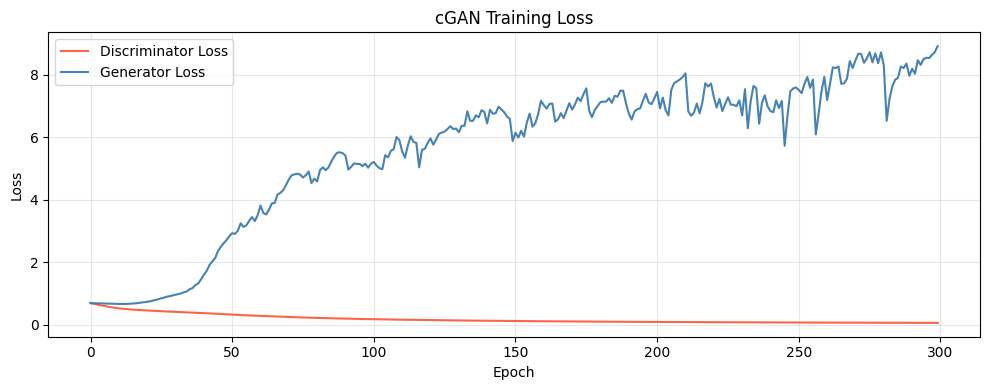

In [67]:
plt.figure(figsize=(10, 4))
plt.plot(d_losses, label='Discriminator Loss', color='tomato')
plt.plot(g_losses, label='Generator Loss',     color='steelblue')
plt.title('cGAN Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

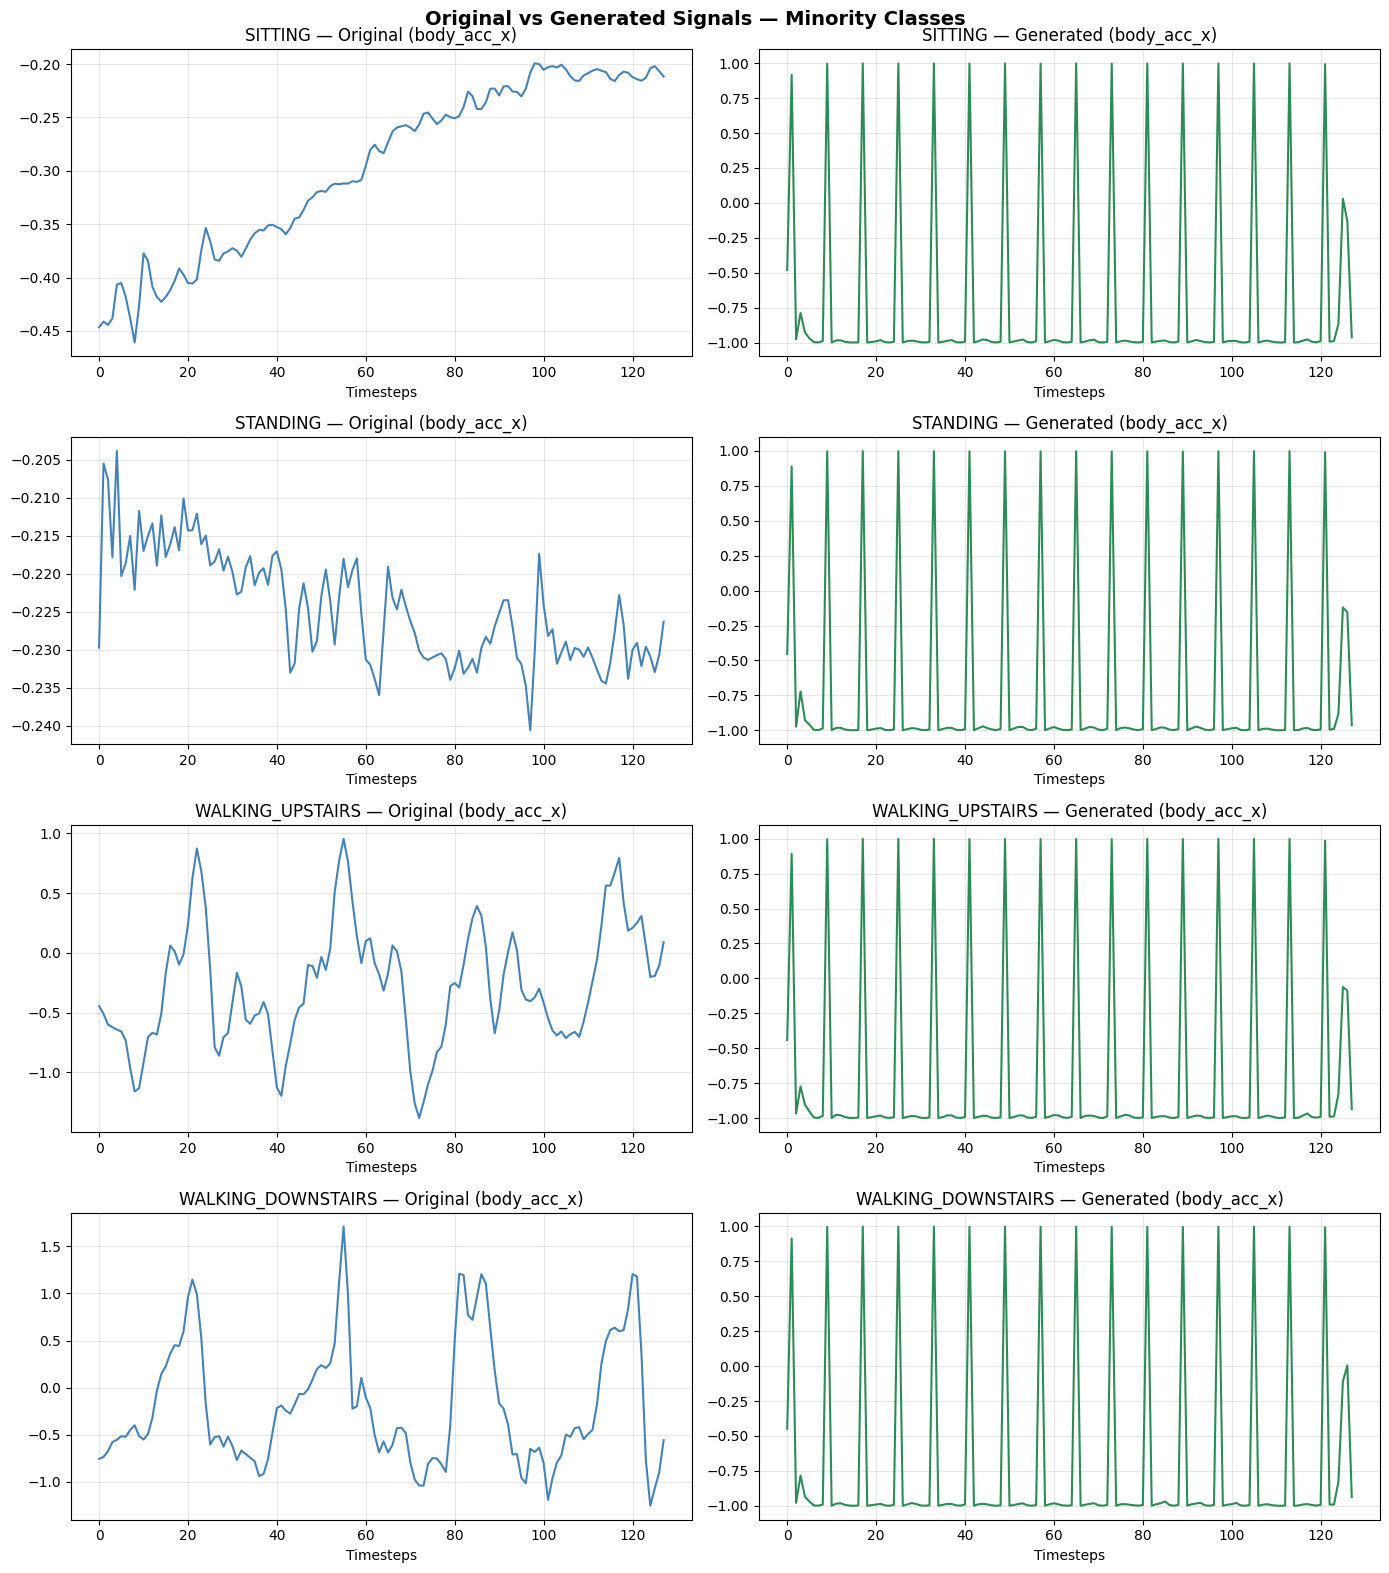

In [68]:
fig, axes = plt.subplots(len(minority_classes), 2, figsize=(14, 4 * len(minority_classes)))
fig.suptitle('Original vs Generated Signals — Minority Classes', fontsize=14, fontweight='bold')

for i, act in enumerate(minority_classes):
    act_id = le_cnn.transform([act])[0]

    # Original
    idx_real  = np.where(y_minority == act_id)[0][0]
    real_sig  = X_minority_norm[idx_real]

    # Generated
    noise     = np.random.normal(0, 1, (1, LATENT_DIM))
    lbl       = np.array([[act_id]])
    fake_sig  = generator.predict([noise, lbl], verbose=0)[0]

    axes[i, 0].plot(real_sig[:, 0], color='steelblue')
    axes[i, 0].set_title(f'{act} — Original (body_acc_x)')
    axes[i, 0].set_xlabel('Timesteps')
    axes[i, 0].grid(True, alpha=0.3)

    axes[i, 1].plot(fake_sig[:, 0], color='seagreen')
    axes[i, 1].set_title(f'{act} — Generated (body_acc_x)')
    axes[i, 1].set_xlabel('Timesteps')
    axes[i, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

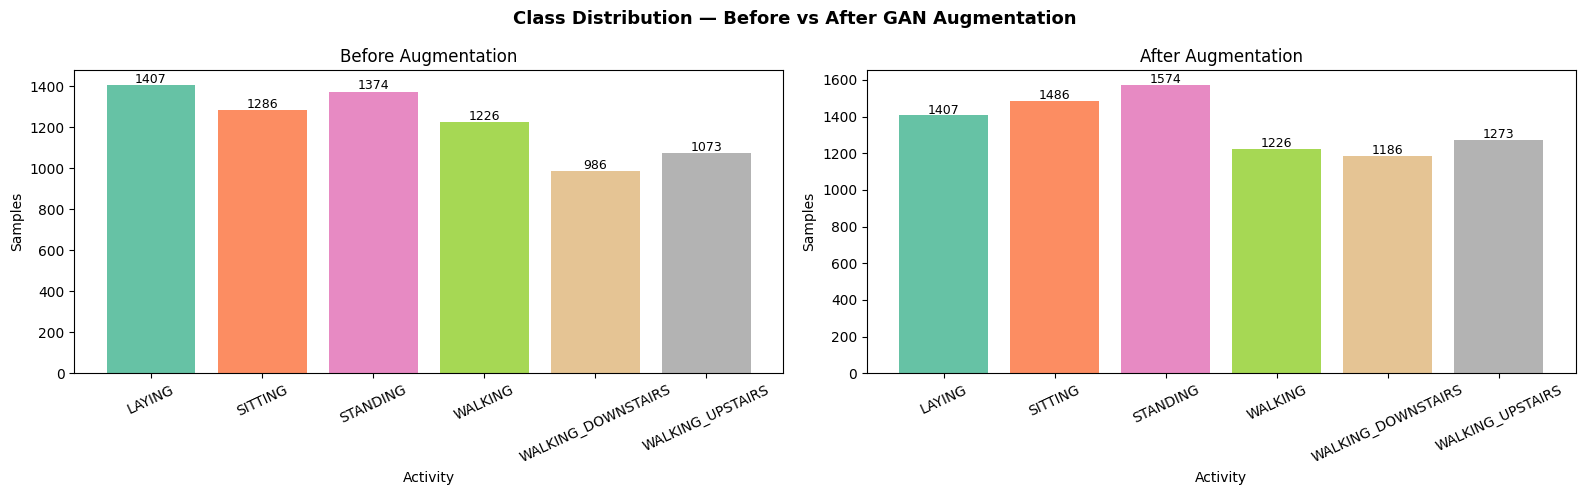

Generated samples added : 800
New total train samples : 8152


In [69]:
n_generate_per_class = 200

X_generated = []
y_generated = []

for act in minority_classes:
    act_id = le_cnn.transform([act])[0]
    noise  = np.random.normal(0, 1, (n_generate_per_class, LATENT_DIM))
    lbls   = np.full((n_generate_per_class, 1), act_id)
    fakes  = generator.predict([noise, lbls], verbose=0)
    X_generated.append(fakes)
    y_generated.append(np.full(n_generate_per_class, act_id))

X_generated = np.concatenate(X_generated, axis=0)
y_generated = np.concatenate(y_generated, axis=0)

# Before
before_unique, before_counts = np.unique(
    le_cnn.inverse_transform(np.argmax(y_train_oh, axis=1)), return_counts=True)

# After
y_train_labels_all = list(le_cnn.inverse_transform(np.argmax(y_train_oh, axis=1))) + \
                     list(le_cnn.inverse_transform(y_generated))
after_unique, after_counts = np.unique(y_train_labels_all, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Class Distribution — Before vs After GAN Augmentation', fontsize=13, fontweight='bold')

axes[0].bar(before_unique, before_counts, color=plt.cm.Set2(np.linspace(0, 1, len(before_unique))))
axes[0].set_title('Before Augmentation')
axes[0].set_xlabel('Activity')
axes[0].set_ylabel('Samples')
axes[0].tick_params(axis='x', rotation=25)
for i, (act, cnt) in enumerate(zip(before_unique, before_counts)):
    axes[0].text(i, cnt + 10, str(cnt), ha='center', fontsize=9)

axes[1].bar(after_unique, after_counts, color=plt.cm.Set2(np.linspace(0, 1, len(after_unique))))
axes[1].set_title('After Augmentation')
axes[1].set_xlabel('Activity')
axes[1].set_ylabel('Samples')
axes[1].tick_params(axis='x', rotation=25)
for i, (act, cnt) in enumerate(zip(after_unique, after_counts)):
    axes[1].text(i, cnt + 10, str(cnt), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Generated samples added : {len(X_generated)}')
print(f'New total train samples : {len(y_train_labels_all)}')

## Applied on the best Phase-1 model (Random Forest / Gradient Boosting)

In [70]:
# ── SHAP Cell 1 : Install & import SHAP ─────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'shap'], check=False)

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(f'SHAP version : {shap.__version__}')
shap.initjs()

SHAP version : 0.50.0


In [85]:
# ── SHAP Cell 2 : Identify best Phase-1 tree model ──────────────────────
# Relies on: trained_models, results_df  (created in Phase 1 Cell 17)

tree_names   = ['Random Forest', 'Gradient Boosting']
tree_results = results_df[results_df['Model'].isin(tree_names)].copy()

best_tree_name  = tree_results.loc[tree_results['Accuracy'].idxmax(), 'Model']
best_tree_model = trained_models[best_tree_name][0]

print('=== Phase-1 Tree Models ===')
print(tree_results[['Model','Accuracy','F1 Score','ROC AUC']].to_string(index=False))
print(f'\n✔  Best model selected for SHAP : {best_tree_name}')

=== Phase-1 Tree Models ===
            Model  Accuracy  F1 Score  ROC AUC
    Random Forest    0.9019    0.9017   0.9914
Gradient Boosting    0.9104    0.9103   0.9924

✔  Best model selected for SHAP : Gradient Boosting


In [77]:
print(f'Building TreeExplainer for [Random Forest] …')

# Get Random Forest model from trained_models dictionary
rf_model = trained_models['Random Forest'][0]

# Build explainer
explainer = shap.TreeExplainer(rf_model)

# Use the full test set for explanations
X_explain = X_test

# Compute SHAP values
shap_values = explainer.shap_values(X_explain)

print('SHAP values computed successfully!')

Building TreeExplainer for [Random Forest] …
SHAP values computed successfully!


In [87]:
# ── SHAP Cell 3
print(f'Building Explainer for [{best_tree_name}] …')

X_explain = X_test.copy()

if best_tree_name == 'Gradient Boosting':
    # GradientBoostingClassifier multiclass not supported by TreeExplainer
    # Use KernelExplainer with a background sample instead
    background = shap.sample(X_train, 100)
    explainer  = shap.KernelExplainer(best_tree_model.predict_proba, background)
    # Use a subset of test set (KernelExplainer is slow)
    X_explain  = X_test.iloc[:200].copy()
    shap_values_raw = explainer.shap_values(X_explain, nsamples=100)
else:
    explainer       = shap.TreeExplainer(best_tree_model)
    shap_values_raw = explainer.shap_values(X_explain)

# Normalize to list of arrays, one per class
if isinstance(shap_values_raw, list):
    shap_values = shap_values_raw
else:
    shap_values = [shap_values_raw[:, :, i] for i in range(shap_values_raw.shape[2])]

print(f'  Classes         : {len(shap_values)}')
print(f'  Shape per class : {shap_values[0].shape}')
print('Done!')

Building Explainer for [Gradient Boosting] …


  0%|          | 0/200 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 5 iterations, i.e. alpha=2.156e-03, with an active set of 5 regressors, and the smallest cholesky pivot element being 2.220e-16. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 6 iterations, i.e. alpha=8.322e-03, with an active set of 6 regressors, and the smallest cholesky pivot element being 8.429e-08. Reduce max_iter or increase eps parameters.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_least_angle.py:723: ConvergenceWarning: Regressors in active set degenerate. Dropping a regressor, after 4 iterations, i.e. alpha=2.497e-02, with an active set of 4 regressors, and the smallest cholesky pivot element being 7

  Classes         : 6
  Shape per class : (200, 90)
Done!


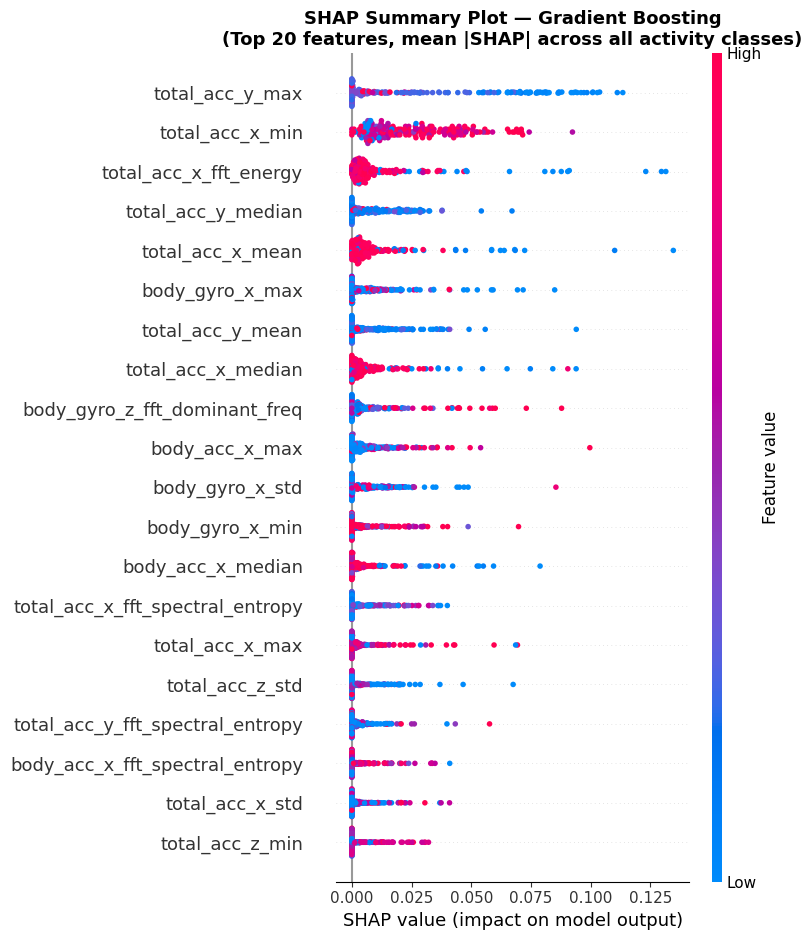

Saved → shap_summary_beeswarm.png


In [88]:
# ── SHAP Cell 4 : Summary Plot (beeswarm) — mean |SHAP| across all classes
# Stack class-level SHAP arrays → mean absolute impact per feature

if isinstance(shap_values, list):
    # Mean absolute SHAP over all classes: shape (n_samples, n_features)
    shap_mean = np.mean(np.abs(np.array(shap_values)), axis=0)
else:
    shap_mean = shap_values

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_mean,
    X_explain,
    plot_type='dot',        # beeswarm — shows distribution + direction
    max_display=20,
    show=False
)
plt.title(f'SHAP Summary Plot — {best_tree_name}\n(Top 20 features, mean |SHAP| across all activity classes)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_summary_beeswarm.png')

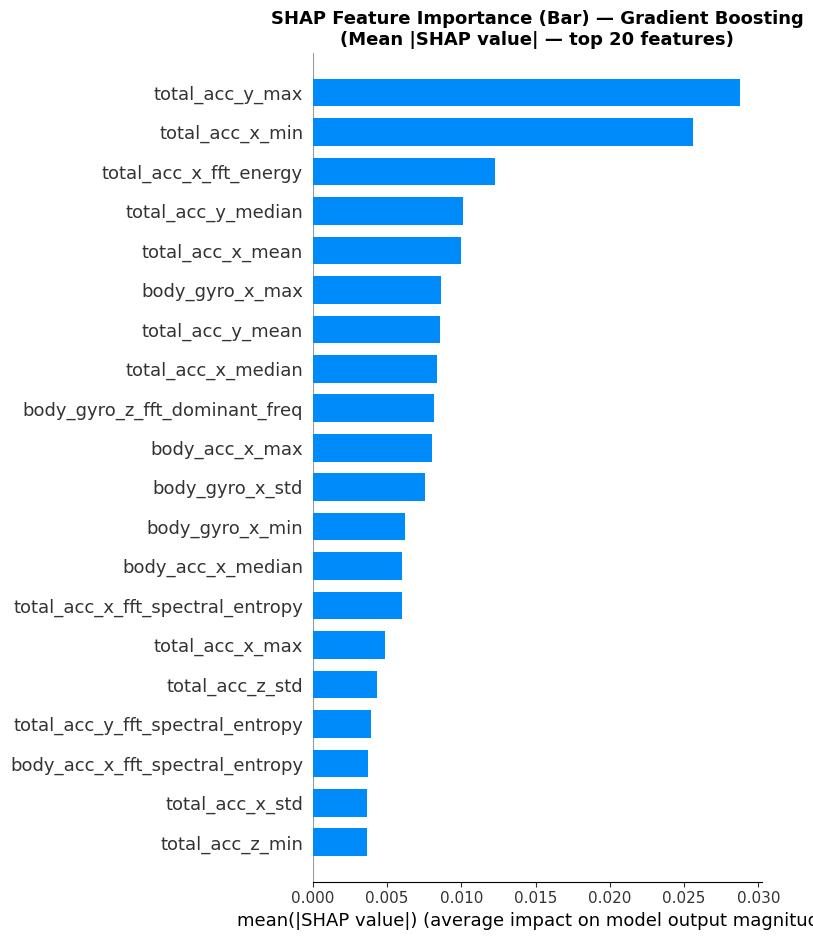

Saved → shap_bar_global.png


In [89]:
# ── SHAP Cell 5 : Bar Plot — Global Feature Importance ──────────────────

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_mean,
    X_explain,
    plot_type='bar',
    max_display=20,
    show=False
)
plt.title(f'SHAP Feature Importance (Bar) — {best_tree_name}\n(Mean |SHAP value| — top 20 features)',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_bar_global.png')

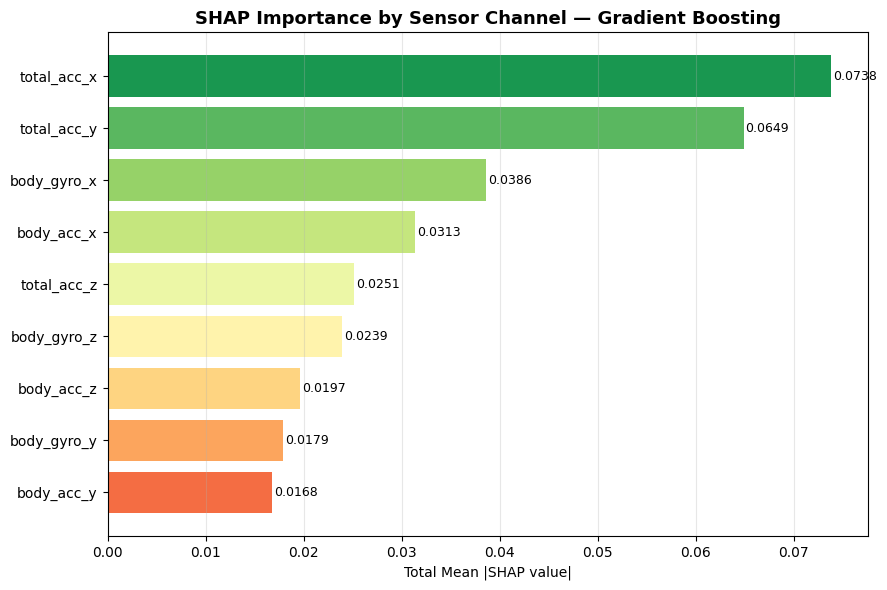

Saved → shap_bar_per_channel.png
Sensor Channel  Total Mean |SHAP|
   total_acc_x           0.073832
   total_acc_y           0.064883
   body_gyro_x           0.038592
    body_acc_x           0.031327
   total_acc_z           0.025142
   body_gyro_z           0.023905
    body_acc_z           0.019668
   body_gyro_y           0.017941
    body_acc_y           0.016758


In [90]:
# ── SHAP Cell 6 : Per-Sensor-Channel Feature Importance ─────────────────
# The 90 engineered features are prefixed by sensor channel name.
# We group mean |SHAP| by sensor to show which physical signal matters most.

SENSOR_CHANNELS = [
    'body_acc_x',  'body_acc_y',  'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z'
]

mean_abs_shap = pd.Series(
    np.mean(np.abs(shap_mean), axis=0),
    index=X_explain.columns
)

channel_importance = {}
for ch in SENSOR_CHANNELS:
    cols = [c for c in X_explain.columns if c.startswith(ch)]
    channel_importance[ch] = mean_abs_shap[cols].sum() if cols else 0.0

ch_df = pd.DataFrame(list(channel_importance.items()),
                     columns=['Sensor Channel', 'Total Mean |SHAP|'])
ch_df = ch_df.sort_values('Total Mean |SHAP|', ascending=True)

# ── Plot
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(ch_df)))
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(ch_df['Sensor Channel'], ch_df['Total Mean |SHAP|'], color=colors)
for bar in bars:
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.4f}', va='center', fontsize=9)
ax.set_xlabel('Total Mean |SHAP value|')
ax.set_title(f'SHAP Importance by Sensor Channel — {best_tree_name}',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('shap_bar_per_channel.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_bar_per_channel.png')
print(ch_df.sort_values('Total Mean |SHAP|', ascending=False).to_string(index=False))

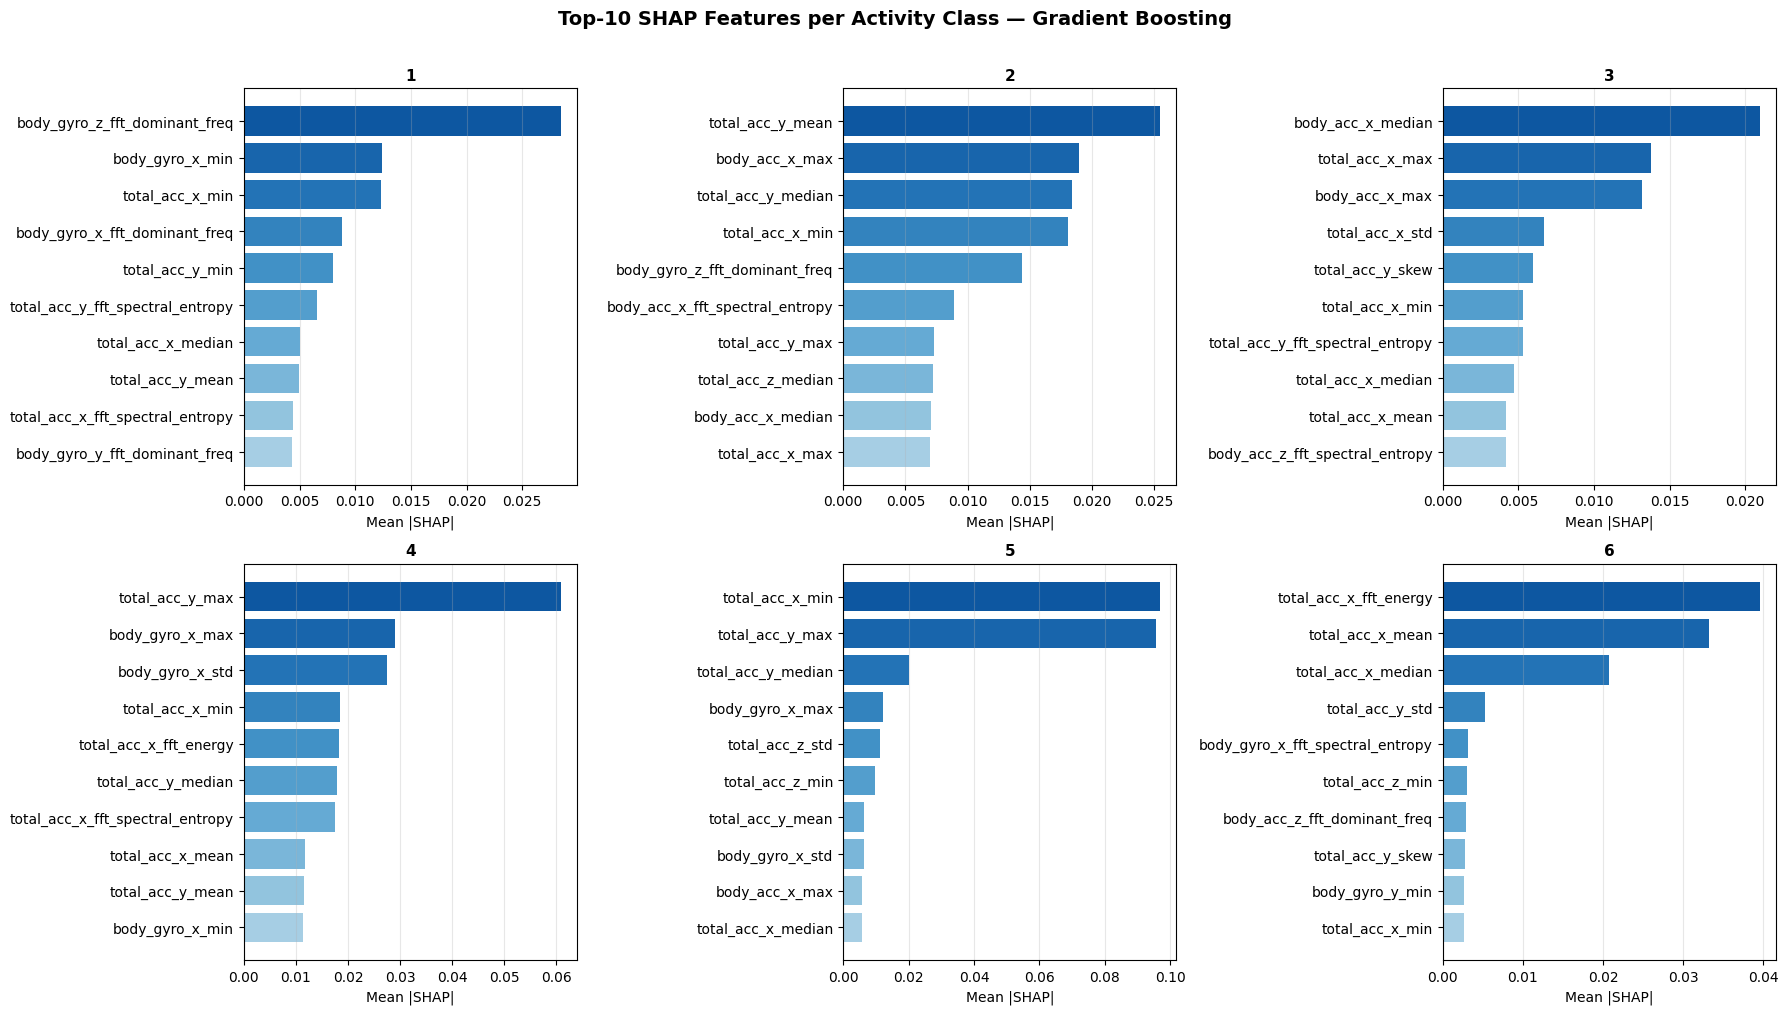

Saved → shap_per_class.png


In [91]:
# ── SHAP Cell 7 : Per-Class SHAP Bar Plots — top 10 features each class

if isinstance(shap_values, list):
    class_labels = le.classes_          # label encoder from Phase 1
    n_classes    = len(class_labels)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, (ax, cls) in enumerate(zip(axes, class_labels)):
        sv_cls = np.abs(shap_values[i])      # (n_samples, n_features)
        mean_sv = pd.Series(sv_cls.mean(axis=0), index=X_explain.columns)
        top10   = mean_sv.nlargest(10).sort_values()

        colors_cls = plt.cm.Blues(np.linspace(0.35, 0.85, len(top10)))
        ax.barh(top10.index, top10.values, color=colors_cls)
        ax.set_title(f'{cls}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Mean |SHAP|')
        ax.grid(axis='x', alpha=0.3)

    # Hide any unused axes
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f'Top-10 SHAP Features per Activity Class — {best_tree_name}',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('shap_per_class.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved → shap_per_class.png')
else:
    print('Single-output model — skipping per-class breakdown.')

Top global feature : total_acc_y_max


<Figure size 800x500 with 0 Axes>

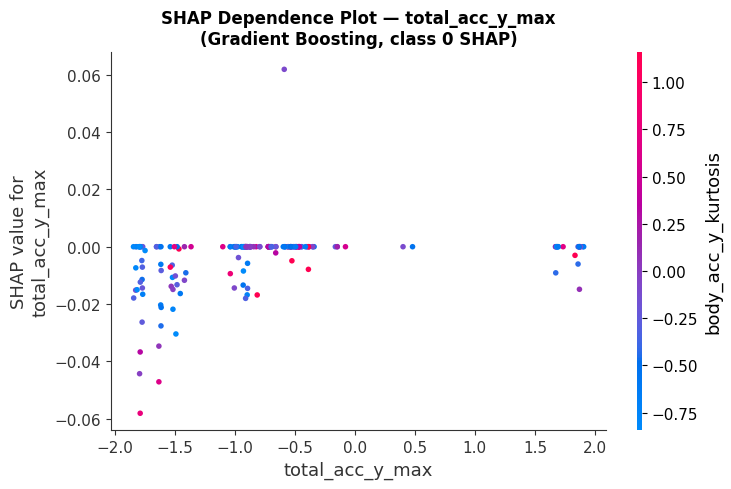

Saved → shap_dependence_top.png


In [92]:
# ── SHAP Cell 8 : Dependence Plot — top global feature ──────────────────
# Shows how the top feature's value maps to its SHAP impact.

top_feature = mean_abs_shap.idxmax()
print(f'Top global feature : {top_feature}')

# Use class 0 SHAP values if multi-class, else flat array
sv_for_dep = shap_values[0] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_feature,
    sv_for_dep,
    X_explain,
    interaction_index='auto',   # auto-selects the most correlated feature for colour
    show=False
)
plt.title(f'SHAP Dependence Plot — {top_feature}\n({best_tree_name}, class 0 SHAP)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_dependence_top.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_dependence_top.png')

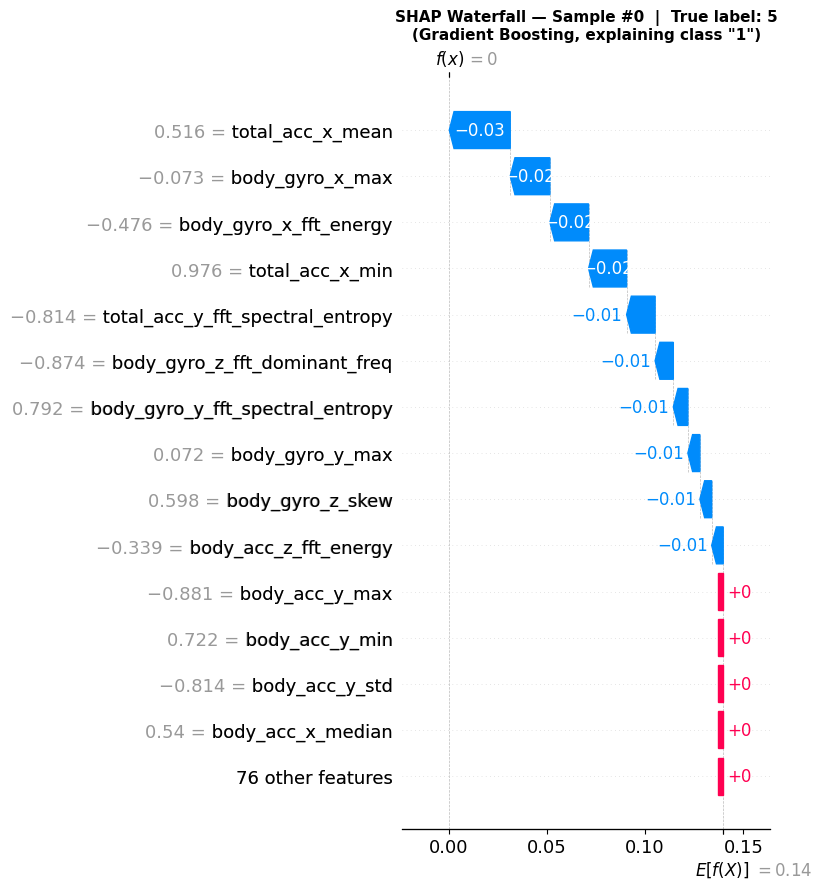

Saved → shap_waterfall_sample0.png


In [93]:
# ── SHAP Cell 9 : Waterfall Plot — single sample explanation ────────────
# Pick one test sample (index 0) and show how each feature pushed the
# prediction away from the base value.

sample_idx = 0
cls_idx    = 0   # explain with respect to class 0 (first activity)

if isinstance(shap_values, list):
    sv_sample = shap_values[cls_idx][sample_idx]   # (n_features,)
    ev        = explainer.expected_value[cls_idx]
else:
    sv_sample = shap_values[sample_idx]
    ev        = explainer.expected_value

explanation = shap.Explanation(
    values        = sv_sample,
    base_values   = ev,
    data          = X_explain.iloc[sample_idx].values,
    feature_names = X_explain.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(explanation, max_display=15, show=False)
true_label = le.classes_[best_tree_model.predict(X_explain.iloc[[sample_idx]])[0]]
plt.title(f'SHAP Waterfall — Sample #{sample_idx}  |  True label: {true_label}\n'
          f'({best_tree_name}, explaining class "{le.classes_[cls_idx]}")',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_waterfall_sample0.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → shap_waterfall_sample0.png')

In [94]:
# ── SHAP Cell 10 : Top-20 Global Feature Importance Table ───────────────

top20 = mean_abs_shap.nlargest(20).reset_index()
top20.columns = ['Feature', 'Mean |SHAP|']
top20['Rank'] = range(1, 21)
top20 = top20[['Rank', 'Feature', 'Mean |SHAP|']]

print(f'=== Top-20 Global SHAP Features — {best_tree_name} ===')
print(top20.to_string(index=False))

# Also print channel summary
print('\n=== Sensor Channel Importance (summed SHAP) ===')
print(ch_df.sort_values('Total Mean |SHAP|', ascending=False).to_string(index=False))

=== Top-20 Global SHAP Features — Gradient Boosting ===
 Rank                          Feature  Mean |SHAP|
    1                  total_acc_y_max     0.028782
    2                  total_acc_x_min     0.025617
    3           total_acc_x_fft_energy     0.012244
    4               total_acc_y_median     0.010144
    5                 total_acc_x_mean     0.009959
    6                  body_gyro_x_max     0.008624
    7                 total_acc_y_mean     0.008533
    8               total_acc_x_median     0.008372
    9    body_gyro_z_fft_dominant_freq     0.008174
   10                   body_acc_x_max     0.008017
   11                  body_gyro_x_std     0.007527
   12                  body_gyro_x_min     0.006200
   13                body_acc_x_median     0.006008
   14 total_acc_x_fft_spectral_entropy     0.006007
   15                  total_acc_x_max     0.004890
   16                  total_acc_z_std     0.004331
   17 total_acc_y_fft_spectral_entropy     0.003884
   18  b